Analysis complete. Optimal rank cutoff found at: 27
Plot saved as: rank_validation_elbow.png


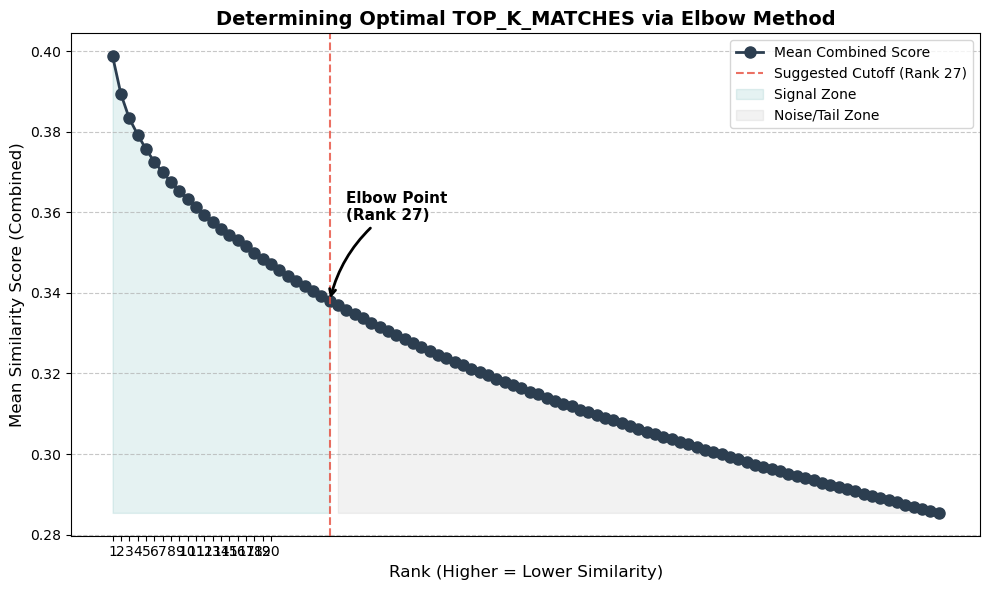

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =============================================================================
# CONFIGURATION
# =============================================================================
INPUT_FILE = '20_gene_to_mz_synced_results_v1_analytic_fast/gene_to_mz_top20_matches_all_scores.csv'
SAVE_PLOT = "rank_validation_elbow.png"

def find_elbow_geometric(x, y):
    """
    Finds the elbow point using the distance from the line connecting 
    the first and last points.
    """
    # Vector from first to last point
    n_points = len(x)
    first_point = np.array([x[0], y[0]])
    line_vec = np.array([x[-1], y[-1]]) - first_point
    line_vec_norm = line_vec / np.sqrt(np.sum(line_vec**2))

    # Vector from first point to all points
    vec_from_first = np.array([x, y]).T - first_point

    # Distance to line: ||vec - (vec.line_norm) * line_norm||
    scalar_proj = np.dot(vec_from_first, line_vec_norm)
    vec_proj = np.outer(scalar_proj, line_vec_norm)
    dist_to_line = np.sqrt(np.sum((vec_from_first - vec_proj)**2, axis=1))

    # The elbow is the point with the maximum distance
    return x[np.argmax(dist_to_line)]

def run_analysis(file_path):
    # 1. Load data
    try:
        df = pd.read_csv(file_path)
    except FileNotFoundError:
        print(f"Error: File {file_path} not found.")
        return

    # 2. Aggregate scores by Rank
    # We average across all genes and samples to find the 'global' cutoff
    rank_stats = df.groupby('rank')['combined_score'].mean().reset_index()
    
    ranks = rank_stats['rank'].values
    scores = rank_stats['combined_score'].values

    # 3. Calculate Elbow
    elbow_rank = find_elbow_geometric(ranks, scores)

    # 4. Plotting
    plt.figure(figsize=(10, 6))
    
    # Plot the scores
    plt.plot(ranks, scores, 'o-', color='#2c3e50', label='Mean Combined Score', linewidth=2, markersize=8)
    
    # Highlight the elbow
    plt.axvline(x=elbow_rank, color='#e74c3c', linestyle='--', alpha=0.8,
                label=f'Suggested Cutoff (Rank {elbow_rank})')
    
    plt.fill_between(ranks, scores.min(), scores, where=(ranks <= elbow_rank), 
                     color='teal', alpha=0.1, label='Signal Zone')
    plt.fill_between(ranks, scores.min(), scores, where=(ranks > elbow_rank), 
                     color='gray', alpha=0.1, label='Noise/Tail Zone')

    # Formatting
    plt.title('Determining Optimal TOP_K_MATCHES via Elbow Method', fontsize=14, fontweight='bold')
    plt.xlabel('Rank (Higher = Lower Similarity)', fontsize=12)
    plt.ylabel('Mean Similarity Score (Combined)', fontsize=12)
    plt.xticks(np.arange(1, 21, 1))
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend()

    # Annotation
    elbow_score = scores[np.where(ranks == elbow_rank)[0][0]]
    plt.annotate(f'Elbow Point\n(Rank {elbow_rank})', 
                 xy=(elbow_rank, elbow_score), 
                 xytext=(elbow_rank+2, elbow_score+0.02),
                 arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=.2', color='black', lw=2),
                 fontsize=11, fontweight='bold')

    plt.tight_layout()
    #plt.savefig(SAVE_PLOT, dpi=300)
    print(f"Analysis complete. Optimal rank cutoff found at: {elbow_rank}")
    print(f"Plot saved as: {SAVE_PLOT}")
    plt.show()

if __name__ == "__main__":
    run_analysis(INPUT_FILE)

Loaded 160000 total matches across 20 genes
Rank range: 1 to 500

=== GLOBAL CUTOFF SUGGESTIONS ===
Geometric Elbow Method: Rank 78
Derivative Method: Rank 366
Gap Statistic Method: Rank 500

=== PER-GENE ANALYSIS ===
Median suggested cutoff across genes: 1.0
Mean suggested cutoff across genes: 1.0

Per-gene cutoff distribution:
      gene  top1_score  suggested_cutoff
AC149090.1    0.433825                 1
     Aplp1    0.459905                 1
      Apoe    0.491169                 1
       App    0.383240                 1
    Atp1a3    0.364009                 1
    Elavl3    0.346387                 1
      Eno1    0.332628                 1
      Gnas    0.457868                 1
  Hsp90ab1    0.432926                 1
      Mapt    0.364857                 1
      Meg3    0.421622                 1
       Pkm    0.357873                 1
      Pmch    0.269136                 1
      Rac1    0.411638                 1
   Rasgrf1    0.393136                 1
     Rsrp1   

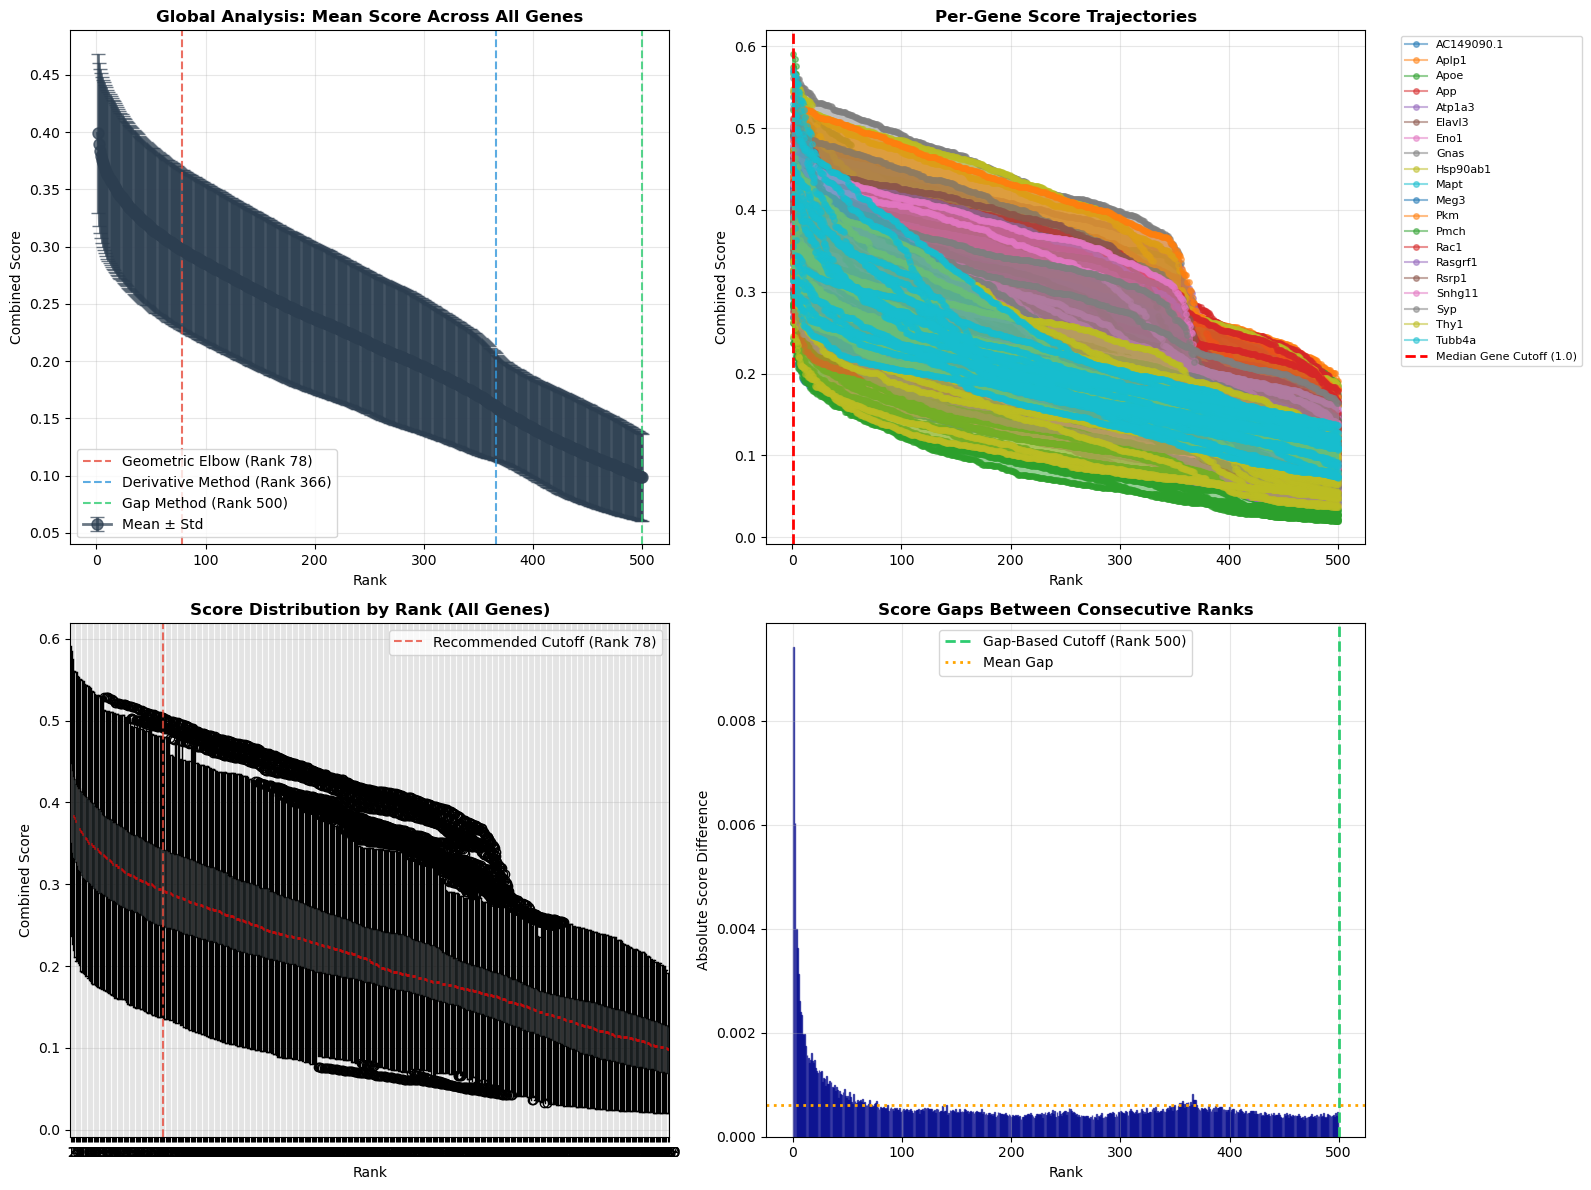


FINAL RECOMMENDATION
Recommended TOP_K_MATCHES: 1

Rationale:
  - Conservative choice (minimum of all methods)
  - Balances signal quality vs. noise inclusion
  - Accounts for per-gene variability

If you need more candidates for downstream filtering:
  - Consider TOP_K = 78



In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from sklearn.preprocessing import StandardScaler

# =============================================================================
# CONFIGURATION
# =============================================================================
INPUT_FILE = '500_gene_to_mz_synced_results_v1_analytic_fast/gene_to_mz_top500_matches_all_scores.csv'
SAVE_DIR = "rank_validation_analysis/"
import os
os.makedirs(SAVE_DIR, exist_ok=True)

def find_elbow_geometric(x, y):
    """Original geometric method"""
    n_points = len(x)
    first_point = np.array([x[0], y[0]])
    line_vec = np.array([x[-1], y[-1]]) - first_point
    line_vec_norm = line_vec / np.sqrt(np.sum(line_vec**2))
    vec_from_first = np.array([x, y]).T - first_point
    scalar_proj = np.dot(vec_from_first, line_vec_norm)
    vec_proj = np.outer(scalar_proj, line_vec_norm)
    dist_to_line = np.sqrt(np.sum((vec_from_first - vec_proj)**2, axis=1))
    return x[np.argmax(dist_to_line)]

def find_elbow_derivative(x, y):
    """
    Finds elbow using second derivative (rate of change of rate of change).
    More sensitive to subtle changes in curvature.
    """
    # First derivative (rate of change)
    dy = np.gradient(y)
    # Second derivative (curvature)
    d2y = np.gradient(dy)
    # Find where curvature is maximum (most negative for decreasing function)
    return x[np.argmin(d2y)]

def find_elbow_gap_statistic(x, y, threshold=0.05):
    """
    Finds elbow where the gap between consecutive points becomes small.
    Useful when there's a clear "quality gap" between signal and noise.
    """
    gaps = np.abs(np.diff(y))
    # Normalize gaps
    gaps_norm = gaps / gaps.max()
    # Find first point where gap drops below threshold
    small_gaps = np.where(gaps_norm < threshold)[0]
    if len(small_gaps) > 0:
        return x[small_gaps[0] + 1]  # +1 because diff reduces length by 1
    return x[-1]

def analyze_per_gene_distribution(df):
    """
    Analyze score distribution for each gene separately.
    Returns per-gene statistics and suggested cutoffs.
    """
    genes = df['gene'].unique()
    gene_stats = []
    
    for gene in genes:
        gene_df = df[df['gene'] == gene].sort_values('rank')
        ranks = gene_df['rank'].values
        scores = gene_df['combined_score'].values
        
        # Calculate metrics
        score_range = scores.max() - scores.min()
        mean_score = scores.mean()
        top1_score = scores[0] if len(scores) > 0 else 0
        
        # Find where score drops below 80% of top score
        threshold_80 = 0.8 * top1_score
        cutoff_80 = np.where(scores < threshold_80)[0]
        rank_at_80 = ranks[cutoff_80[0]] if len(cutoff_80) > 0 else len(ranks)
        
        # Calculate gap-based cutoff
        gaps = np.abs(np.diff(scores))
        if len(gaps) > 0:
            mean_gap = gaps.mean()
            std_gap = gaps.std()
            large_gaps = np.where(gaps > (mean_gap + std_gap))[0]
            gap_based_cutoff = ranks[large_gaps[0] + 1] if len(large_gaps) > 0 else len(ranks)
        else:
            gap_based_cutoff = len(ranks)
        
        gene_stats.append({
            'gene': gene,
            'score_range': score_range,
            'mean_score': mean_score,
            'top1_score': top1_score,
            'rank_at_80pct': rank_at_80,
            'gap_based_cutoff': gap_based_cutoff,
            'suggested_cutoff': min(rank_at_80, gap_based_cutoff)
        })
    
    return pd.DataFrame(gene_stats)

def run_comprehensive_analysis(file_path):
    # 1. Load data
    try:
        df = pd.read_csv(file_path)
    except FileNotFoundError:
        print(f"Error: File {file_path} not found.")
        return
    
    print(f"Loaded {len(df)} total matches across {df['gene'].nunique()} genes")
    print(f"Rank range: {df['rank'].min()} to {df['rank'].max()}")
    
    # 2. Global analysis (averaged across genes)
    rank_stats = df.groupby('rank').agg({
        'combined_score': ['mean', 'std', 'median', 'min', 'max']
    }).reset_index()
    rank_stats.columns = ['rank', 'mean_score', 'std_score', 'median_score', 'min_score', 'max_score']
    
    ranks = rank_stats['rank'].values
    mean_scores = rank_stats['mean_score'].values
    std_scores = rank_stats['std_score'].values
    
    # 3. Calculate different elbow points
    elbow_geometric = find_elbow_geometric(ranks, mean_scores)
    elbow_derivative = find_elbow_derivative(ranks, mean_scores)
    elbow_gap = find_elbow_gap_statistic(ranks, mean_scores, threshold=0.03)
    
    print(f"\n=== GLOBAL CUTOFF SUGGESTIONS ===")
    print(f"Geometric Elbow Method: Rank {elbow_geometric}")
    print(f"Derivative Method: Rank {elbow_derivative}")
    print(f"Gap Statistic Method: Rank {elbow_gap}")
    
    # 4. Per-gene analysis
    gene_stats = analyze_per_gene_distribution(df)
    median_gene_cutoff = gene_stats['suggested_cutoff'].median()
    mean_gene_cutoff = gene_stats['suggested_cutoff'].mean()
    
    print(f"\n=== PER-GENE ANALYSIS ===")
    print(f"Median suggested cutoff across genes: {median_gene_cutoff:.1f}")
    print(f"Mean suggested cutoff across genes: {mean_gene_cutoff:.1f}")
    print(f"\nPer-gene cutoff distribution:")
    print(gene_stats[['gene', 'top1_score', 'suggested_cutoff']].to_string(index=False))
    
    # Save gene statistics
    gene_stats.to_csv(f"{SAVE_DIR}per_gene_cutoff_analysis.csv", index=False)
    
    # 5. Create comprehensive visualization
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Plot 1: Global mean with error bars
    ax1 = axes[0, 0]
    ax1.errorbar(ranks, mean_scores, yerr=std_scores, fmt='o-', color='#2c3e50',
                 label='Mean ± Std', linewidth=2, markersize=8, capsize=5, alpha=0.7)
    ax1.axvline(x=elbow_geometric, color='#e74c3c', linestyle='--', alpha=0.8,
                label=f'Geometric Elbow (Rank {elbow_geometric})')
    ax1.axvline(x=elbow_derivative, color='#3498db', linestyle='--', alpha=0.8,
                label=f'Derivative Method (Rank {elbow_derivative})')
    ax1.axvline(x=elbow_gap, color='#2ecc71', linestyle='--', alpha=0.8,
                label=f'Gap Method (Rank {elbow_gap})')
    ax1.fill_between(ranks, mean_scores - std_scores, mean_scores + std_scores,
                     alpha=0.2, color='#2c3e50')
    ax1.set_title('Global Analysis: Mean Score Across All Genes', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Rank')
    ax1.set_ylabel('Combined Score')
    ax1.legend()
    ax1.grid(alpha=0.3)
    
    # Plot 2: Per-gene trajectories
    ax2 = axes[0, 1]
    for gene in df['gene'].unique():
        gene_df = df[df['gene'] == gene].sort_values('rank')
        ax2.plot(gene_df['rank'], gene_df['combined_score'], 'o-', alpha=0.5, label=gene, markersize=4)
    ax2.axvline(x=median_gene_cutoff, color='red', linestyle='--', linewidth=2,
                label=f'Median Gene Cutoff ({median_gene_cutoff:.1f})')
    ax2.set_title('Per-Gene Score Trajectories', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Rank')
    ax2.set_ylabel('Combined Score')
    ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax2.grid(alpha=0.3)
    
    # Plot 3: Score distribution by rank (boxplot)
    ax3 = axes[1, 0]
    rank_groups = [df[df['rank'] == r]['combined_score'].values for r in ranks]
    bp = ax3.boxplot(rank_groups, positions=ranks, widths=0.6, patch_artist=True,
                     boxprops=dict(facecolor='lightblue', alpha=0.7),
                     medianprops=dict(color='red', linewidth=2))
    ax3.axvline(x=elbow_geometric, color='#e74c3c', linestyle='--', alpha=0.8,
                label=f'Recommended Cutoff (Rank {elbow_geometric})')
    ax3.set_title('Score Distribution by Rank (All Genes)', fontsize=12, fontweight='bold')
    ax3.set_xlabel('Rank')
    ax3.set_ylabel('Combined Score')
    ax3.legend()
    ax3.grid(alpha=0.3)
    
    # Plot 4: Gap analysis
    ax4 = axes[1, 1]
    gaps = np.abs(np.diff(mean_scores))
    gap_ranks = ranks[:-1]
    ax4.bar(gap_ranks, gaps, color='steelblue', alpha=0.7, edgecolor='darkblue')
    ax4.axvline(x=elbow_gap, color='#2ecc71', linestyle='--', linewidth=2,
                label=f'Gap-Based Cutoff (Rank {elbow_gap})')
    mean_gap = gaps.mean()
    ax4.axhline(y=mean_gap, color='orange', linestyle=':', linewidth=2, label='Mean Gap')
    ax4.set_title('Score Gaps Between Consecutive Ranks', fontsize=12, fontweight='bold')
    ax4.set_xlabel('Rank')
    ax4.set_ylabel('Absolute Score Difference')
    ax4.legend()
    ax4.grid(alpha=0.3)
    
    plt.tight_layout()
    #plt.savefig(f"{SAVE_DIR}comprehensive_rank_analysis.png", dpi=300, bbox_inches='tight')
    print(f"\nPlot saved as: {SAVE_DIR}comprehensive_rank_analysis.png")
    plt.show()
    
    # 6. Final recommendation
    print(f"\n{'='*70}")
    print("FINAL RECOMMENDATION")
    print(f"{'='*70}")
    
    # Conservative: take the minimum of all methods
    recommended_cutoff = int(min(elbow_geometric, elbow_derivative, elbow_gap, median_gene_cutoff))
    
    print(f"Recommended TOP_K_MATCHES: {recommended_cutoff}")
    print(f"\nRationale:")
    print(f"  - Conservative choice (minimum of all methods)")
    print(f"  - Balances signal quality vs. noise inclusion")
    print(f"  - Accounts for per-gene variability")
    print(f"\nIf you need more candidates for downstream filtering:")
    print(f"  - Consider TOP_K = {int(max(elbow_geometric, median_gene_cutoff))}")
    print(f"{'='*70}\n")
    
    return recommended_cutoff, gene_stats

if __name__ == "__main__":
    recommended_k, gene_stats = run_comprehensive_analysis(INPUT_FILE)

GENE-TO-M/Z RANK ANALYSIS WITH PARENT/CHILD FILTERING


MODE 1: PARENTS ONLY (Remove all children)
Loaded 160000 matches from 500_gene_to_mz_synced_results_v1_analytic_fast/gene_to_mz_top500_matches_all_scores.csv
Loaded hierarchy: 154 parents, 260 children

FILTERING MODE: PARENTS_ONLY

Filtering results:
  Total matches: 160000
  Parents (with children): 46094 (28.8%)
  Standalone (no children): 35069 (21.9%)
  Children (FILTERED OUT): 78837 (49.3%)
  Total KEPT: 81163 (50.7%)

Filtered results saved to: rank_validation_analysis/filtered_matches_parents_only.csv

ELBOW DETECTION RESULTS (After Filtering)
Geometric Elbow Method: Rank 80
Derivative Method: Rank 45
Gap Statistic Method: Rank 32

Plot saved to: rank_validation_analysis/rank_analysis_parents_only.png


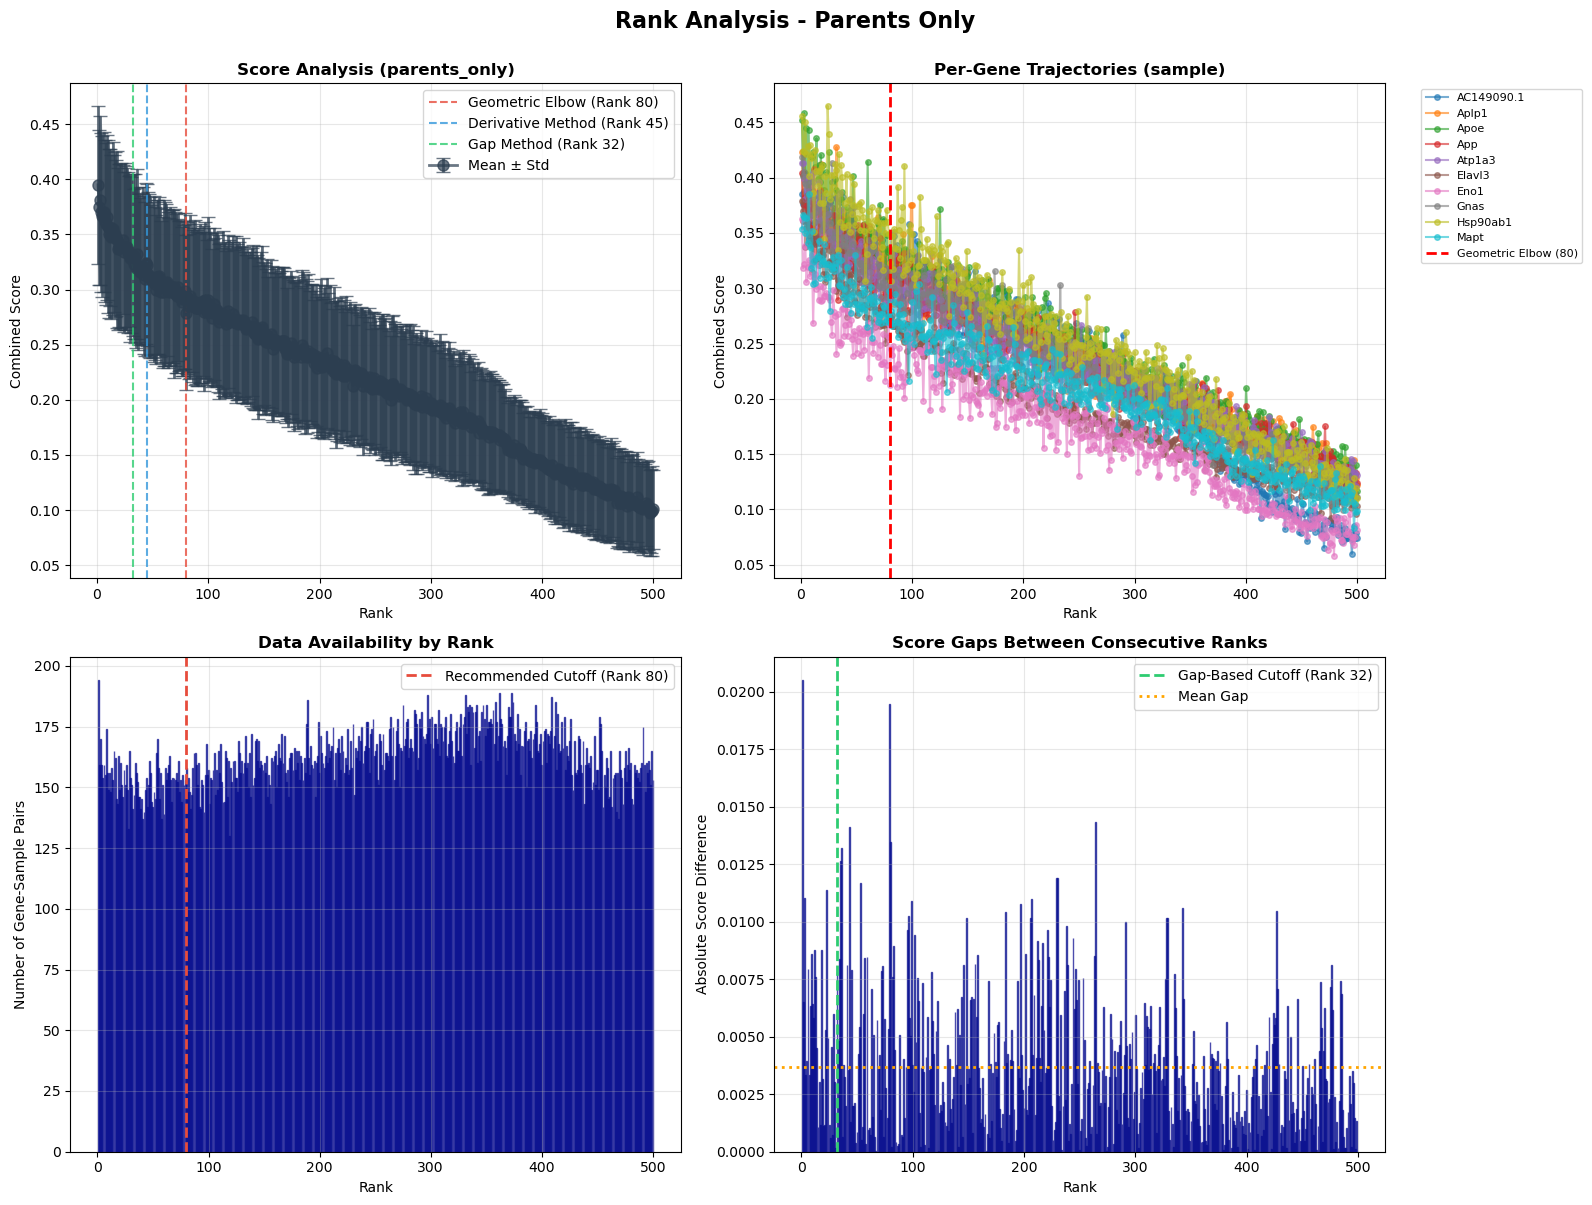


SUMMARY STATISTICS
Total matches after filtering: 81163
Unique genes: 20
Unique samples: 16
Max rank observed: 500

Score statistics:
  Mean: 0.2142
  Std: 0.0913
  Min: 0.0201
  Max: 0.5908

RECOMMENDATION
Recommended cutoff rank: 45
  (Based on minimum of Geometric and Derivative methods)
This represents the optimal balance between signal and noise
after parents_only filtering.



MODE 2: AGGREGATE (Combine children scores with parent)
Loaded 160000 matches from 500_gene_to_mz_synced_results_v1_analytic_fast/gene_to_mz_top500_matches_all_scores.csv
Loaded hierarchy: 154 parents, 260 children

FILTERING MODE: AGGREGATE

Aggregation results:
  Original matches: 160000
    - Parents: 46094
    - Standalone: 35069
    - Children: 78837
  After aggregation: 83678 unique parent/standalone entries
  Average family size: 1.91

Filtered results saved to: rank_validation_analysis/filtered_matches_aggregate.csv

ELBOW DETECTION RESULTS (After Filtering)
Geometric Elbow Method: Rank 132
Derivat

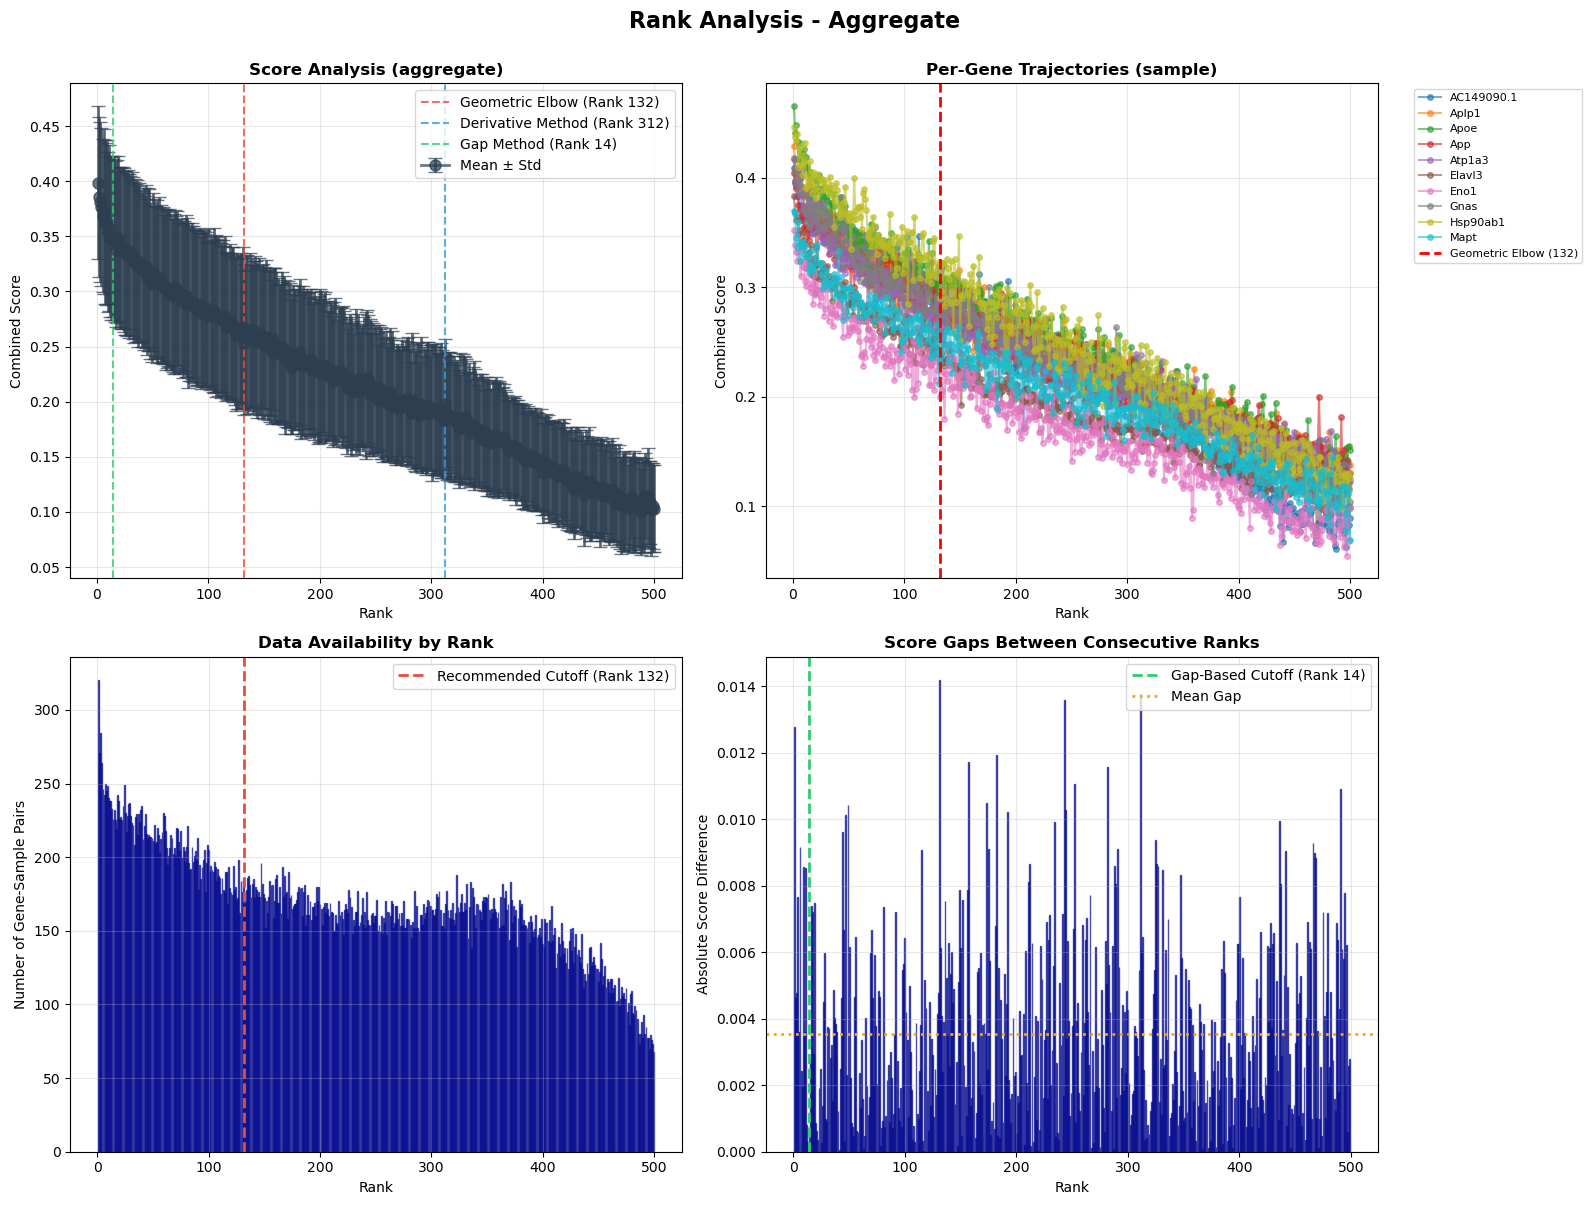


SUMMARY STATISTICS
Total matches after filtering: 83678
Unique genes: 20
Unique samples: 16
Max rank observed: 500

Score statistics:
  Mean: 0.2277
  Std: 0.0931
  Min: 0.0200
  Max: 0.5908

RECOMMENDATION
Recommended cutoff rank: 132
  (Based on minimum of Geometric and Derivative methods)
This represents the optimal balance between signal and noise
after aggregate filtering.



MODE 3: NO FILTERING (Original data)
Loaded 160000 matches from 500_gene_to_mz_synced_results_v1_analytic_fast/gene_to_mz_top500_matches_all_scores.csv
Loaded hierarchy: 154 parents, 260 children

FILTERING MODE: NONE
No filtering applied (using all matches)

Filtered results saved to: rank_validation_analysis/filtered_matches_none.csv

ELBOW DETECTION RESULTS (After Filtering)
Geometric Elbow Method: Rank 78
Derivative Method: Rank 366
Gap Statistic Method: Rank 500

Plot saved to: rank_validation_analysis/rank_analysis_none.png


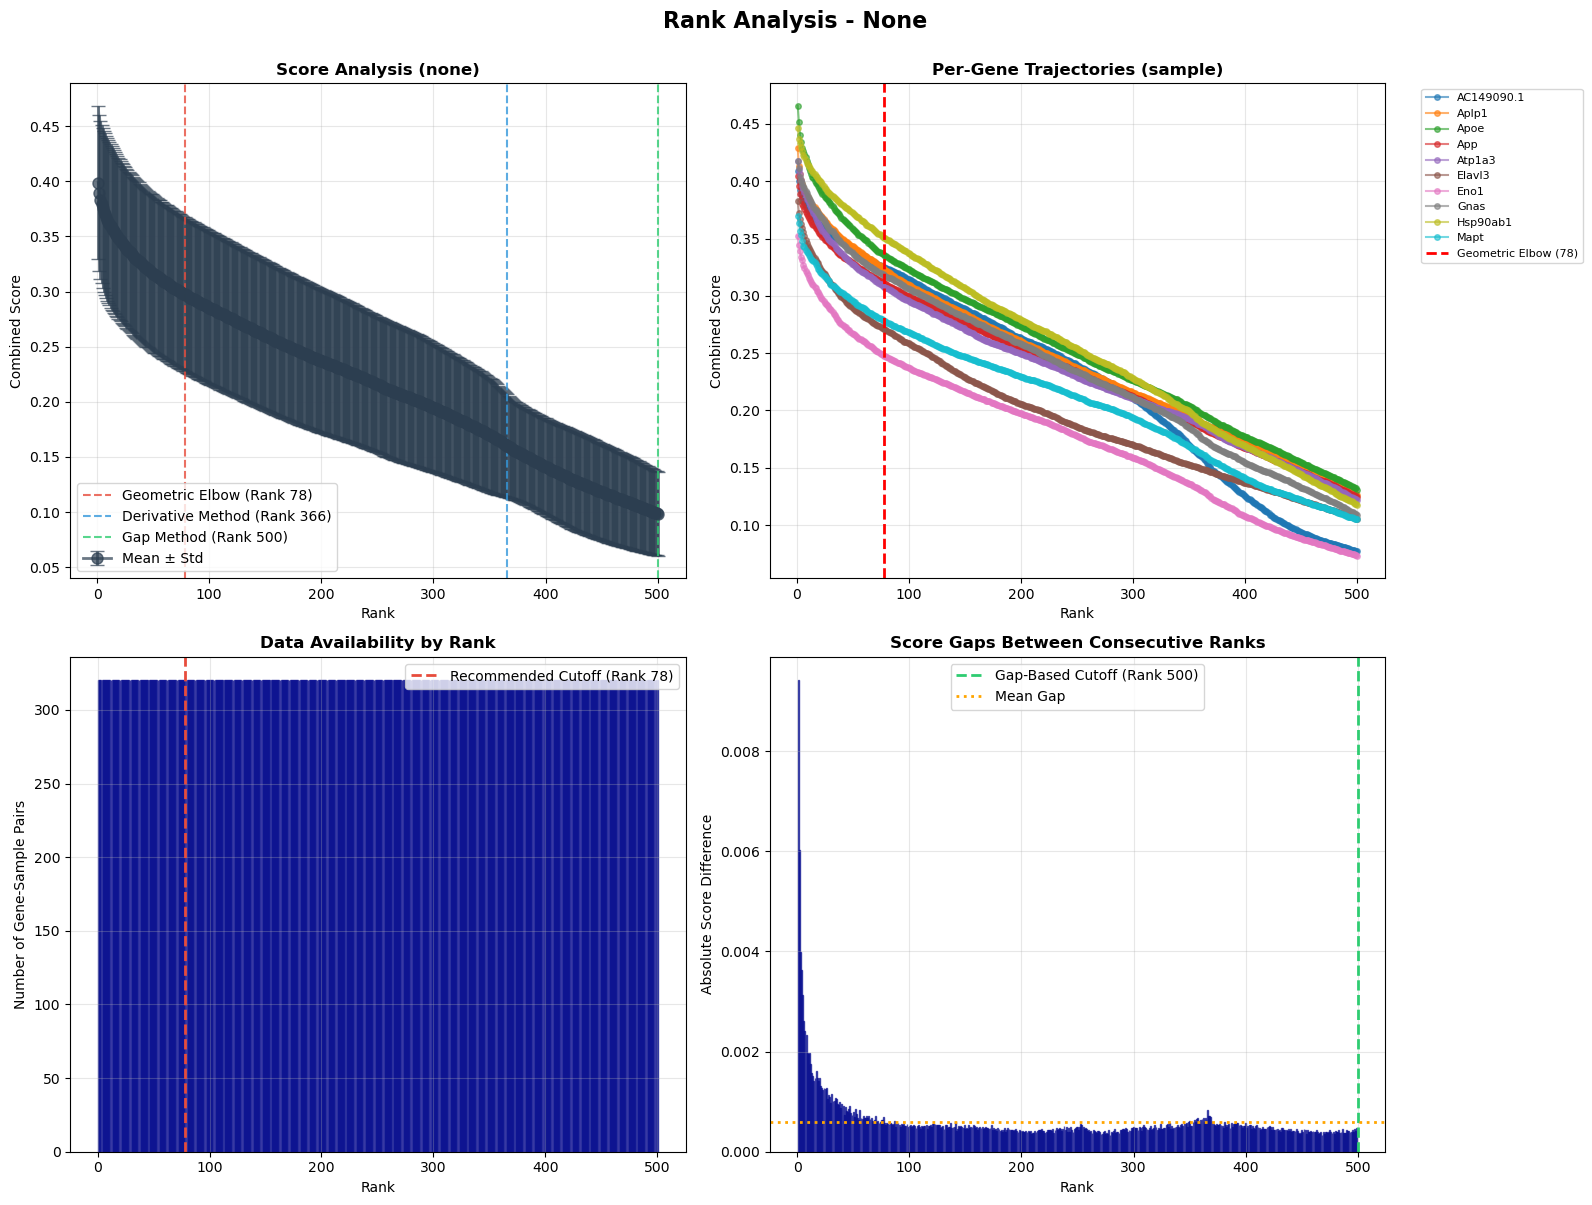


SUMMARY STATISTICS
Total matches after filtering: 160000
Unique genes: 20
Unique samples: 16
Max rank observed: 500

Score statistics:
  Mean: 0.2169
  Std: 0.0940
  Min: 0.0200
  Max: 0.5908

RECOMMENDATION
Recommended cutoff rank: 78
  (Based on minimum of Geometric and Derivative methods)
This represents the optimal balance between signal and noise
after none filtering.



COMPARATIVE SUMMARY
Filtering Mode       Elbow Rank      Total Matches   Avg Score      
----------------------------------------------------------------------
Parents Only         45              81163           0.2142         
Aggregate            132             83678           0.2277         
No Filtering         78              160000          0.2169         


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# =============================================================================
# CONFIGURATION
# =============================================================================
INPUT_FILE = '500_gene_to_mz_synced_results_v1_analytic_fast/gene_to_mz_top500_matches_all_scores.csv'
PARENT_CHILD_FILE = "/home/ajarrah/PhD_Thesis/chapter_4/code_final/2_mz_synced_isotope_80_matching_results/parent_children_hierarchy.csv"
SAVE_DIR = "rank_validation_analysis/"
os.makedirs(SAVE_DIR, exist_ok=True)

# =============================================================================
# PARENT/CHILD FILTERING UTILITIES - CORRECTED
# =============================================================================

def load_parent_child_hierarchy(filepath):
    """
    Load parent-child relationships and create lookup dictionaries.
    Returns:
        - parent_set: Set of all parent m/z values
        - child_set: Set of all child m/z values (to be filtered out)
        - child_to_parent: Dict mapping child m/z to parent m/z
        - parent_to_children: Dict mapping parent m/z to list of children
    """
    df = pd.read_csv(filepath)
    
    parent_set = set()
    child_set = set()
    child_to_parent = {}
    parent_to_children = {}
    
    for _, row in df.iterrows():
        parent = row['Parent_MZ']
        parent_set.add(parent)
        
        children = []
        for col in ['Child_1', 'Child_2', 'Child_3', 'Child_4', 'Child_5']:
            if pd.notna(row[col]):
                child = row[col]
                children.append(child)
                child_set.add(child)
                child_to_parent[child] = parent
        
        if children:
            parent_to_children[parent] = children
    
    print(f"Loaded hierarchy: {len(parent_set)} parents, {len(child_set)} children")
    return parent_set, child_set, child_to_parent, parent_to_children

def match_mz_to_hierarchy(mz_feature, parent_set, child_set, child_to_parent, tolerance=0.01):
    """
    Match an m/z feature string to parent/child hierarchy.
    
    Args:
        mz_feature: String like "339.2312" or "mz_339.2312"
        parent_set: Set of parent m/z values
        child_set: Set of child m/z values
        child_to_parent: Dict mapping child to parent
        tolerance: Matching tolerance for floating point comparison
    
    Returns:
        - 'child': It's a child ion (should be filtered out)
        - 'parent': It's a parent ion (has children, keep it)
        - 'standalone': Not in hierarchy (no children, keep it)
    """
    # Extract numeric m/z value from string
    try:
        mz_str = str(mz_feature).replace('mz_', '').split('_')[0].strip()
        mz_value = float(mz_str)
    except (ValueError, AttributeError):
        return 'standalone'  # Can't parse, assume standalone
    
    # Check if it's a child FIRST (these should be filtered out)
    for child in child_set:
        if abs(mz_value - child) <= tolerance:
            return 'child'
    
    # Check if it's a parent (has children listed)
    for parent in parent_set:
        if abs(mz_value - parent) <= tolerance:
            return 'parent'
    
    # Not in hierarchy at all = standalone parent (no children detected)
    return 'standalone'

def filter_to_parents_only(df, parent_set, child_set, child_to_parent, mz_column='mz_feature', tolerance=0.001):
    """
    Filter dataframe to REMOVE ONLY child ions.
    Keep both: (1) parents with children, and (2) standalone m/z with no children.
    
    CORRECTED LOGIC:
    - Remove ONLY if m/z is in Child_1-5 columns (child/isotope/adduct)
    - Keep if m/z is in Parent_MZ column (explicit parent)
    - Keep if m/z is NOT in hierarchy at all (standalone, no children)
    
    Args:
        df: DataFrame with match results
        parent_set: Set of parent m/z values
        child_set: Set of child m/z values
        child_to_parent: Dict mapping child to parent
        mz_column: Column name containing m/z feature
        tolerance: Matching tolerance
    
    Returns:
        Filtered DataFrame with only parent and standalone ions (children removed)
    """
    def should_keep(mz_feature):
        result = match_mz_to_hierarchy(mz_feature, parent_set, child_set, child_to_parent, tolerance)
        # Keep parents and standalone, remove only children
        return result in ['parent', 'standalone']
    
    mask = df[mz_column].apply(should_keep)
    n_total = len(df)
    n_kept = mask.sum()
    n_removed = n_total - n_kept
    
    # Additional statistics
    def get_category(mz):
        return match_mz_to_hierarchy(mz, parent_set, child_set, child_to_parent, tolerance)
    
    categories = df[mz_column].apply(get_category)
    n_parents = (categories == 'parent').sum()
    n_standalone = (categories == 'standalone').sum()
    n_children = (categories == 'child').sum()
    
    print(f"\nFiltering results:")
    print(f"  Total matches: {n_total}")
    print(f"  Parents (with children): {n_parents} ({n_parents/n_total*100:.1f}%)")
    print(f"  Standalone (no children): {n_standalone} ({n_standalone/n_total*100:.1f}%)")
    print(f"  Children (FILTERED OUT): {n_children} ({n_children/n_total*100:.1f}%)")
    print(f"  Total KEPT: {n_kept} ({n_kept/n_total*100:.1f}%)")
    
    return df[mask].copy()

def aggregate_children_to_parent(df, parent_set, child_set, child_to_parent, mz_column='mz_feature', 
                                  score_column='combined_score', tolerance=0.001):
    """
    Aggregate child matches to their parent, keeping the best score.
    For standalone m/z (not in hierarchy), keep as-is.
    
    CORRECTED LOGIC:
    - Children are aggregated to their parents
    - Standalone m/z (not in hierarchy) are kept as individual entries
    - Parents without matches through children are kept as-is
    
    Args:
        df: DataFrame with match results
        parent_set: Set of parent m/z values
        child_set: Set of child m/z values
        child_to_parent: Dict mapping child to parent
        mz_column: Column name containing m/z feature
        score_column: Column name containing similarity score
        tolerance: Matching tolerance
    
    Returns:
        DataFrame with children aggregated to parents, standalone kept separate
    """
    df = df.copy()
    
    def get_parent_assignment(mz_feature):
        """Return the parent m/z this feature should be grouped with"""
        result = match_mz_to_hierarchy(mz_feature, parent_set, child_set, child_to_parent, tolerance)
        
        try:
            mz_str = str(mz_feature).replace('mz_', '').split('_')[0].strip()
            mz_value = float(mz_str)
        except:
            return None
        
        if result == 'child':
            # It's a child, map to parent
            for child, parent in child_to_parent.items():
                if abs(mz_value - child) <= tolerance:
                    return parent
        elif result == 'parent':
            # It's a parent, map to itself
            return mz_value
        else:  # standalone
            # Not in hierarchy, map to itself (will be kept as individual entry)
            return mz_value
        
        return None
    
    df['parent_mz'] = df[mz_column].apply(get_parent_assignment)
    df_valid = df[df['parent_mz'].notna()].copy()
    
    # Group by gene, sample, and parent_mz, keeping best score
    aggregated = df_valid.loc[df_valid.groupby(['gene', 'rna_sample', 'parent_mz'])[score_column].idxmax()]
    
    # Add metadata about aggregation
    child_counts = df_valid.groupby(['gene', 'rna_sample', 'parent_mz']).size()
    aggregated['n_family_members'] = aggregated.apply(
        lambda row: child_counts.get((row['gene'], row['rna_sample'], row['parent_mz']), 1), axis=1
    )
    
    # Count different types in original data
    def get_category(mz):
        return match_mz_to_hierarchy(mz, parent_set, child_set, child_to_parent, tolerance)
    
    original_categories = df[mz_column].apply(get_category)
    
    print(f"\nAggregation results:")
    print(f"  Original matches: {len(df)}")
    print(f"    - Parents: {(original_categories == 'parent').sum()}")
    print(f"    - Standalone: {(original_categories == 'standalone').sum()}")
    print(f"    - Children: {(original_categories == 'child').sum()}")
    print(f"  After aggregation: {len(aggregated)} unique parent/standalone entries")
    print(f"  Average family size: {aggregated['n_family_members'].mean():.2f}")
    
    return aggregated.drop('parent_mz', axis=1)

# =============================================================================
# ELBOW DETECTION FUNCTIONS
# =============================================================================

def find_elbow_geometric(x, y):
    """Original geometric method"""
    n_points = len(x)
    first_point = np.array([x[0], y[0]])
    line_vec = np.array([x[-1], y[-1]]) - first_point
    line_vec_norm = line_vec / np.sqrt(np.sum(line_vec**2))
    vec_from_first = np.array([x, y]).T - first_point
    scalar_proj = np.dot(vec_from_first, line_vec_norm)
    vec_proj = np.outer(scalar_proj, line_vec_norm)
    dist_to_line = np.sqrt(np.sum((vec_from_first - vec_proj)**2, axis=1))
    return x[np.argmax(dist_to_line)]

def find_elbow_derivative(x, y):
    """Finds elbow using second derivative"""
    dy = np.gradient(y)
    d2y = np.gradient(dy)
    return x[np.argmin(d2y)]

def find_elbow_gap_statistic(x, y, threshold=0.05):
    """Finds elbow where gap between consecutive points becomes small"""
    gaps = np.abs(np.diff(y))
    if len(gaps) == 0:
        return x[-1]
    gaps_norm = gaps / (gaps.max() + 1e-10)
    small_gaps = np.where(gaps_norm < threshold)[0]
    if len(small_gaps) > 0:
        return x[small_gaps[0] + 1]
    return x[-1]

# =============================================================================
# COMPREHENSIVE ANALYSIS WITH PARENT FILTERING
# =============================================================================

def run_comprehensive_analysis_with_filtering(file_path, parent_child_path, 
                                                filter_mode='parents_only'):
    """
    Run comprehensive rank analysis with parent/child filtering.
    
    Args:
        file_path: Path to match results CSV
        parent_child_path: Path to parent-child hierarchy CSV
        filter_mode: 'parents_only', 'aggregate', or 'none'
    """
    # 1. Load data
    try:
        df = pd.read_csv(file_path)
        print(f"Loaded {len(df)} matches from {file_path}")
    except FileNotFoundError:
        print(f"Error: File {file_path} not found.")
        return None, None, None
    
    # 2. Load parent-child hierarchy
    try:
        parent_set, child_set, child_to_parent, parent_to_children = load_parent_child_hierarchy(parent_child_path)
    except FileNotFoundError:
        print(f"Error: Hierarchy file {parent_child_path} not found.")
        return None, None, None
    
    # 3. Apply filtering based on mode
    print(f"\n{'='*70}")
    print(f"FILTERING MODE: {filter_mode.upper()}")
    print(f"{'='*70}")
    
    if filter_mode == 'parents_only':
        df_filtered = filter_to_parents_only(df, parent_set, child_set, child_to_parent)
    elif filter_mode == 'aggregate':
        df_filtered = aggregate_children_to_parent(df, parent_set, child_set, child_to_parent)
    else:
        df_filtered = df.copy()
        print("No filtering applied (using all matches)")
    
    # Save filtered results
    filtered_path = os.path.join(SAVE_DIR, f'filtered_matches_{filter_mode}.csv')
    df_filtered.to_csv(filtered_path, index=False)
    print(f"\nFiltered results saved to: {filtered_path}")
    
    # 4. Compute rank statistics on filtered data
    if 'rank' not in df_filtered.columns:
        # Re-rank after filtering
        print("\nRe-ranking matches after filtering...")
        df_filtered = df_filtered.sort_values(['gene', 'rna_sample', 'combined_score'], 
                                                ascending=[True, True, False])
        df_filtered['rank'] = df_filtered.groupby(['gene', 'rna_sample']).cumcount() + 1
    
    rank_stats = df_filtered.groupby('rank').agg({
        'combined_score': ['mean', 'std', 'median', 'min', 'max', 'count']
    }).reset_index()
    rank_stats.columns = ['rank', 'mean_score', 'std_score', 'median_score', 
                          'min_score', 'max_score', 'count']
    
    ranks = rank_stats['rank'].values
    mean_scores = rank_stats['mean_score'].values
    std_scores = rank_stats['std_score'].values
    counts = rank_stats['count'].values
    
    # 5. Calculate different elbow points
    elbow_geometric = find_elbow_geometric(ranks, mean_scores)
    elbow_derivative = find_elbow_derivative(ranks, mean_scores)
    elbow_gap = find_elbow_gap_statistic(ranks, mean_scores, threshold=0.03)
    
    print(f"\n{'='*70}")
    print("ELBOW DETECTION RESULTS (After Filtering)")
    print(f"{'='*70}")
    print(f"Geometric Elbow Method: Rank {elbow_geometric}")
    print(f"Derivative Method: Rank {elbow_derivative}")
    print(f"Gap Statistic Method: Rank {elbow_gap}")
    
    # 6. Visualization
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Plot 1: Mean score with error bars
    ax1 = axes[0, 0]
    ax1.errorbar(ranks, mean_scores, yerr=std_scores, fmt='o-', color='#2c3e50',
                 label='Mean ± Std', linewidth=2, markersize=8, capsize=5, alpha=0.7)
    ax1.axvline(x=elbow_geometric, color='#e74c3c', linestyle='--', alpha=0.8,
                label=f'Geometric Elbow (Rank {elbow_geometric})')
    ax1.axvline(x=elbow_derivative, color='#3498db', linestyle='--', alpha=0.8,
                label=f'Derivative Method (Rank {elbow_derivative})')
    ax1.axvline(x=elbow_gap, color='#2ecc71', linestyle='--', alpha=0.8,
                label=f'Gap Method (Rank {elbow_gap})')
    ax1.fill_between(ranks, mean_scores - std_scores, mean_scores + std_scores,
                     alpha=0.2, color='#2c3e50')
    ax1.set_title(f'Score Analysis ({filter_mode})', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Rank')
    ax1.set_ylabel('Combined Score')
    ax1.legend()
    ax1.grid(alpha=0.3)
    
    # Plot 2: Per-gene trajectories (sample)
    ax2 = axes[0, 1]
    genes_to_plot = df_filtered['gene'].unique()[:10]  # Plot first 10 genes
    for gene in genes_to_plot:
        gene_df = df_filtered[df_filtered['gene'] == gene].sort_values('rank')
        # Average across samples for cleaner visualization
        gene_rank_avg = gene_df.groupby('rank')['combined_score'].mean()
        ax2.plot(gene_rank_avg.index, gene_rank_avg.values, 'o-', 
                alpha=0.6, label=gene, markersize=4)
    ax2.axvline(x=elbow_geometric, color='red', linestyle='--', linewidth=2,
                label=f'Geometric Elbow ({elbow_geometric})')
    ax2.set_title(f'Per-Gene Trajectories (sample)', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Rank')
    ax2.set_ylabel('Combined Score')
    ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax2.grid(alpha=0.3)
    
    # Plot 3: Data availability by rank
    ax3 = axes[1, 0]
    ax3.bar(ranks, counts, color='steelblue', alpha=0.7, edgecolor='darkblue')
    ax3.axvline(x=elbow_geometric, color='#e74c3c', linestyle='--', linewidth=2,
                label=f'Recommended Cutoff (Rank {elbow_geometric})')
    ax3.set_title('Data Availability by Rank', fontsize=12, fontweight='bold')
    ax3.set_xlabel('Rank')
    ax3.set_ylabel('Number of Gene-Sample Pairs')
    ax3.legend()
    ax3.grid(alpha=0.3)
    
    # Plot 4: Gap analysis
    ax4 = axes[1, 1]
    gaps = np.abs(np.diff(mean_scores))
    gap_ranks = ranks[:-1]
    ax4.bar(gap_ranks, gaps, color='steelblue', alpha=0.7, edgecolor='darkblue')
    ax4.axvline(x=elbow_gap, color='#2ecc71', linestyle='--', linewidth=2,
                label=f'Gap-Based Cutoff (Rank {elbow_gap})')
    mean_gap = gaps.mean()
    ax4.axhline(y=mean_gap, color='orange', linestyle=':', linewidth=2, label='Mean Gap')
    ax4.set_title('Score Gaps Between Consecutive Ranks', fontsize=12, fontweight='bold')
    ax4.set_xlabel('Rank')
    ax4.set_ylabel('Absolute Score Difference')
    ax4.legend()
    ax4.grid(alpha=0.3)
    
    plt.suptitle(f'Rank Analysis - {filter_mode.replace("_", " ").title()}', 
                 fontsize=16, fontweight='bold', y=1.00)
    plt.tight_layout()
    plot_path = os.path.join(SAVE_DIR, f'rank_analysis_{filter_mode}.png')
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    print(f"\nPlot saved to: {plot_path}")
    plt.show()
    
    # 7. Summary statistics
    print(f"\n{'='*70}")
    print("SUMMARY STATISTICS")
    print(f"{'='*70}")
    print(f"Total matches after filtering: {len(df_filtered)}")
    print(f"Unique genes: {df_filtered['gene'].nunique()}")
    print(f"Unique samples: {df_filtered['rna_sample'].nunique()}")
    print(f"Max rank observed: {df_filtered['rank'].max()}")
    print(f"\nScore statistics:")
    print(f"  Mean: {df_filtered['combined_score'].mean():.4f}")
    print(f"  Std: {df_filtered['combined_score'].std():.4f}")
    print(f"  Min: {df_filtered['combined_score'].min():.4f}")
    print(f"  Max: {df_filtered['combined_score'].max():.4f}")
    
    # 8. Final recommendation
    recommended_cutoff = int(min(elbow_geometric, elbow_derivative))  # Exclude gap from recommendation
    
    print(f"\n{'='*70}")
    print("RECOMMENDATION")
    print(f"{'='*70}")
    print(f"Recommended cutoff rank: {recommended_cutoff}")
    print(f"  (Based on minimum of Geometric and Derivative methods)")
    print(f"This represents the optimal balance between signal and noise")
    print(f"after {filter_mode} filtering.")
    print(f"{'='*70}\n")
    
    return df_filtered, recommended_cutoff, rank_stats

# =============================================================================
# MAIN EXECUTION
# =============================================================================

if __name__ == "__main__":
    print("="*70)
    print("GENE-TO-M/Z RANK ANALYSIS WITH PARENT/CHILD FILTERING")
    print("="*70)
    
    # Run analysis with different filtering modes
    print("\n\n" + "="*70)
    print("MODE 1: PARENTS ONLY (Remove all children)")
    print("="*70)
    df_parents, cutoff_parents, stats_parents = run_comprehensive_analysis_with_filtering(
        INPUT_FILE, PARENT_CHILD_FILE, filter_mode='parents_only'
    )
    
    print("\n\n" + "="*70)
    print("MODE 2: AGGREGATE (Combine children scores with parent)")
    print("="*70)
    df_aggregate, cutoff_aggregate, stats_aggregate = run_comprehensive_analysis_with_filtering(
        INPUT_FILE, PARENT_CHILD_FILE, filter_mode='aggregate'
    )
    
    print("\n\n" + "="*70)
    print("MODE 3: NO FILTERING (Original data)")
    print("="*70)
    df_none, cutoff_none, stats_none = run_comprehensive_analysis_with_filtering(
        INPUT_FILE, PARENT_CHILD_FILE, filter_mode='none'
    )
    
    # Comparative summary
    print("\n\n" + "="*70)
    print("COMPARATIVE SUMMARY")
    print("="*70)
    print(f"{'Filtering Mode':<20} {'Elbow Rank':<15} {'Total Matches':<15} {'Avg Score':<15}")
    print("-"*70)
    print(f"{'Parents Only':<20} {cutoff_parents:<15} {len(df_parents):<15} {df_parents['combined_score'].mean():<15.4f}")
    print(f"{'Aggregate':<20} {cutoff_aggregate:<15} {len(df_aggregate):<15} {df_aggregate['combined_score'].mean():<15.4f}")
    print(f"{'No Filtering':<20} {cutoff_none:<15} {len(df_none):<15} {df_none['combined_score'].mean():<15.4f}")
    print("="*70)

THRESHOLD STRATEGY ANALYSIS: CONSTANT K vs PERCENTILE

Loaded 81163 filtered matches (parents only)

ANALYSIS 1: K=45 vs 70th Percentile
THRESHOLD STRATEGY COMPARISON

SUMMARY: Constant K=45 vs 70th Percentile

Metric                                   Constant K           Percentile          
----------------------------------------------------------------------
Total matches kept                       14400                24418               
Avg matches per gene-sample              45.0                 76.3                
Std matches per gene-sample              0.0                  0.9                 
Min matches per gene-sample              45                   73                  
Max matches per gene-sample              45                   78                  
Avg mean score                           0.3241               0.3023              

CASES WITH LARGE DIFFERENCES (|Δn| > 10)
Found 320 gene-sample pairs with significant differences

Top 5 where Constant K keeps MORE:
  

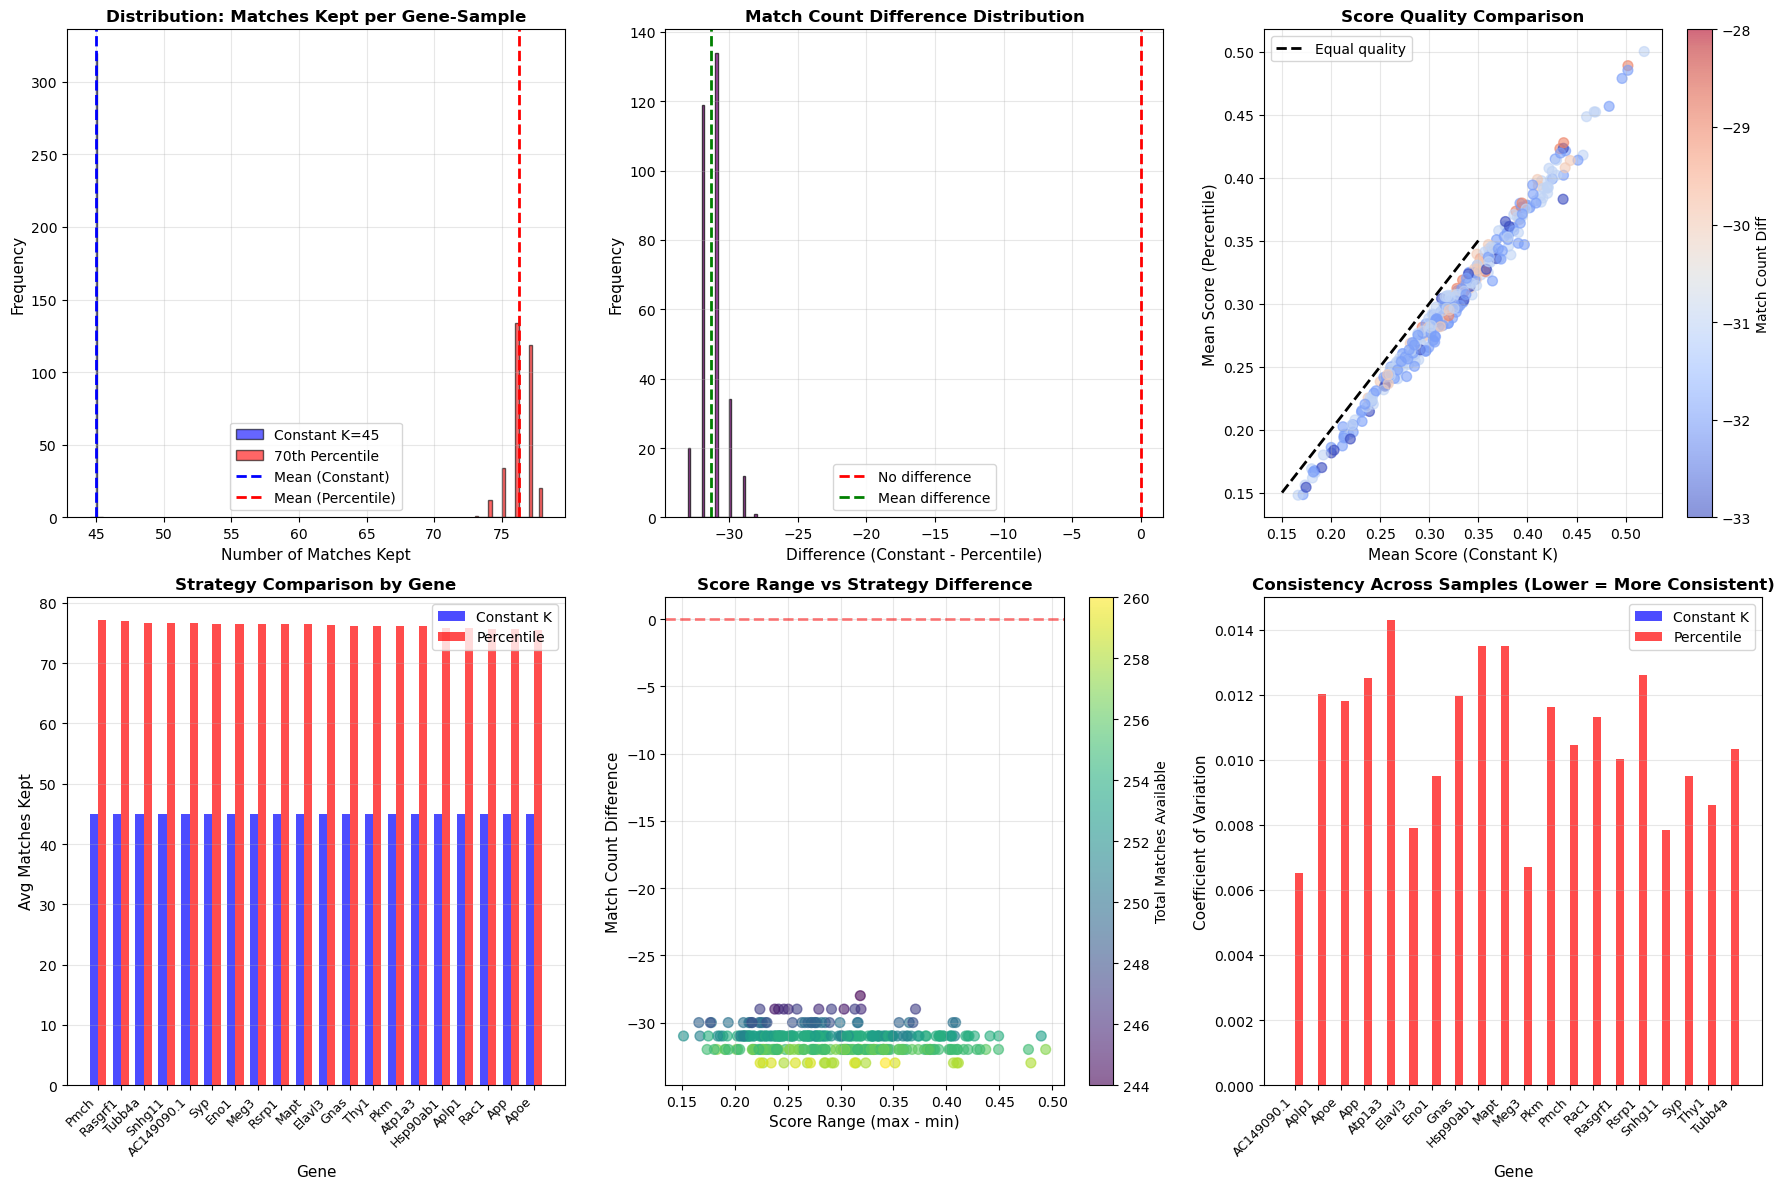


DECISION MATRIX

Criterion                                Winner              
----------------------------------------------------------------------
Consistency across samples               Constant K          
Implementation simplicity                Constant K          
Adapts to data quality                   Percentile          
Average score quality                    Constant K          
Total matches kept                       Percentile          
Interpretability/reproducibility         Constant K          

ANALYSIS 2: Multiple Thresholds

MULTI-THRESHOLD COMPARISON

Strategy        Value      Total Kept      Avg/Pair        Avg Score      
----------------------------------------------------------------------
Constant K      30         9600            30.0            0.3378         
Constant K      40         12800           40.0            0.3283         
Constant K      45         14400           45.0            0.3241         
Constant K      50         16000           5

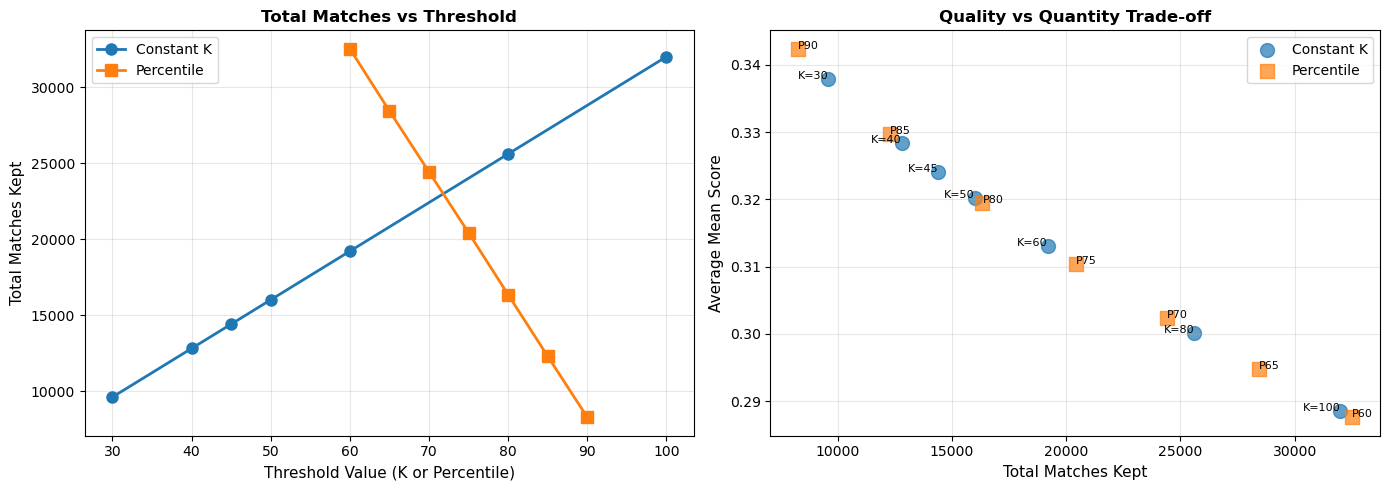


FINAL RECOMMENDATION

For your bioinformatics pipeline, we recommend:

  🎯 USE CONSTANT K = 45-50

Reasons:
  1. Consistent number of matches across all genes/samples
  2. Easier to interpret and reproduce
  3. Aligns with elbow point analysis
  4. Simpler implementation
  5. Better for downstream statistical analysis (equal sample sizes)

When to consider percentile:
  - If genes have vastly different match quality distributions
  - If you need adaptive quality control per gene
  - If computational resources vary by sample




In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# =============================================================================
# CONFIGURATION
# =============================================================================
INPUT_FILE = 'rank_validation_analysis/filtered_matches_parents_only.csv'
SAVE_DIR = "threshold_comparison_analysis/"
os.makedirs(SAVE_DIR, exist_ok=True)

# =============================================================================
# THRESHOLD COMPARISON ANALYSIS
# =============================================================================

def analyze_threshold_strategies(df, constant_k=45, percentile_threshold=70):
    """
    Compare constant-K vs percentile-based thresholding strategies.
    
    Args:
        df: Filtered matches dataframe (parents only)
        constant_k: Fixed number of top matches to keep
        percentile_threshold: Percentile cutoff (e.g., 70 = keep top 30%)
    """
    
    print("="*70)
    print("THRESHOLD STRATEGY COMPARISON")
    print("="*70)
    
    # Analyze per gene-sample pair
    gene_sample_stats = []
    
    for (gene, sample), group in df.groupby(['gene', 'rna_sample']):
        group_sorted = group.sort_values('combined_score', ascending=False)
        
        # Strategy 1: Constant K
        constant_k_actual = min(constant_k, len(group_sorted))
        constant_matches = group_sorted.head(constant_k_actual)
        constant_min_score = constant_matches['combined_score'].min()
        constant_mean_score = constant_matches['combined_score'].mean()
        
        # Strategy 2: Percentile
        score_threshold = np.percentile(group_sorted['combined_score'], percentile_threshold)
        percentile_matches = group_sorted[group_sorted['combined_score'] >= score_threshold]
        percentile_n = len(percentile_matches)
        percentile_mean_score = percentile_matches['combined_score'].mean() if percentile_n > 0 else 0
        
        # Score distribution metrics
        total_available = len(group_sorted)
        score_range = group_sorted['combined_score'].max() - group_sorted['combined_score'].min()
        score_std = group_sorted['combined_score'].std()
        
        gene_sample_stats.append({
            'gene': gene,
            'sample': sample,
            'total_matches': total_available,
            'score_range': score_range,
            'score_std': score_std,
            'max_score': group_sorted['combined_score'].max(),
            'median_score': group_sorted['combined_score'].median(),
            # Constant K stats
            'constant_k': constant_k_actual,
            'constant_min_score': constant_min_score,
            'constant_mean_score': constant_mean_score,
            # Percentile stats
            'percentile_n': percentile_n,
            'percentile_threshold_score': score_threshold,
            'percentile_mean_score': percentile_mean_score,
            # Comparison
            'n_difference': constant_k_actual - percentile_n,
            'score_difference': constant_mean_score - percentile_mean_score
        })
    
    stats_df = pd.DataFrame(gene_sample_stats)
    
    # Summary statistics
    print(f"\n{'='*70}")
    print(f"SUMMARY: Constant K={constant_k} vs {percentile_threshold}th Percentile")
    print(f"{'='*70}")
    
    print(f"\n{'Metric':<40} {'Constant K':<20} {'Percentile':<20}")
    print("-"*70)
    print(f"{'Total matches kept':<40} {stats_df['constant_k'].sum():<20.0f} {stats_df['percentile_n'].sum():<20.0f}")
    print(f"{'Avg matches per gene-sample':<40} {stats_df['constant_k'].mean():<20.1f} {stats_df['percentile_n'].mean():<20.1f}")
    print(f"{'Std matches per gene-sample':<40} {stats_df['constant_k'].std():<20.1f} {stats_df['percentile_n'].std():<20.1f}")
    print(f"{'Min matches per gene-sample':<40} {stats_df['constant_k'].min():<20.0f} {stats_df['percentile_n'].min():<20.0f}")
    print(f"{'Max matches per gene-sample':<40} {stats_df['constant_k'].max():<20.0f} {stats_df['percentile_n'].max():<20.0f}")
    print(f"{'Avg mean score':<40} {stats_df['constant_mean_score'].mean():<20.4f} {stats_df['percentile_mean_score'].mean():<20.4f}")
    
    # Identify cases where strategies differ significantly
    high_diff = stats_df[abs(stats_df['n_difference']) > 10].sort_values('n_difference', ascending=False)
    
    print(f"\n{'='*70}")
    print(f"CASES WITH LARGE DIFFERENCES (|Δn| > 10)")
    print(f"{'='*70}")
    print(f"Found {len(high_diff)} gene-sample pairs with significant differences")
    
    if len(high_diff) > 0:
        print(f"\nTop 5 where Constant K keeps MORE:")
        print(high_diff.head()[['gene', 'sample', 'constant_k', 'percentile_n', 'n_difference', 'constant_mean_score', 'percentile_mean_score']])
        
        print(f"\nTop 5 where Percentile keeps MORE:")
        print(high_diff.tail()[['gene', 'sample', 'constant_k', 'percentile_n', 'n_difference', 'constant_mean_score', 'percentile_mean_score']])
    
    # Visualization
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # Plot 1: Distribution of matches kept
    ax1 = axes[0, 0]
    ax1.hist(stats_df['constant_k'], bins=20, alpha=0.6, label=f'Constant K={constant_k}', color='blue', edgecolor='black')
    ax1.hist(stats_df['percentile_n'], bins=20, alpha=0.6, label=f'{percentile_threshold}th Percentile', color='red', edgecolor='black')
    ax1.axvline(stats_df['constant_k'].mean(), color='blue', linestyle='--', linewidth=2, label='Mean (Constant)')
    ax1.axvline(stats_df['percentile_n'].mean(), color='red', linestyle='--', linewidth=2, label='Mean (Percentile)')
    ax1.set_xlabel('Number of Matches Kept', fontsize=11)
    ax1.set_ylabel('Frequency', fontsize=11)
    ax1.set_title('Distribution: Matches Kept per Gene-Sample', fontsize=12, fontweight='bold')
    ax1.legend()
    ax1.grid(alpha=0.3)
    
    # Plot 2: Difference in number of matches
    ax2 = axes[0, 1]
    ax2.hist(stats_df['n_difference'], bins=30, color='purple', alpha=0.7, edgecolor='black')
    ax2.axvline(0, color='red', linestyle='--', linewidth=2, label='No difference')
    ax2.axvline(stats_df['n_difference'].mean(), color='green', linestyle='--', linewidth=2, label='Mean difference')
    ax2.set_xlabel('Difference (Constant - Percentile)', fontsize=11)
    ax2.set_ylabel('Frequency', fontsize=11)
    ax2.set_title('Match Count Difference Distribution', fontsize=12, fontweight='bold')
    ax2.legend()
    ax2.grid(alpha=0.3)
    
    # Plot 3: Score quality comparison
    ax3 = axes[0, 2]
    ax3.scatter(stats_df['constant_mean_score'], stats_df['percentile_mean_score'], 
                alpha=0.6, s=50, c=stats_df['n_difference'], cmap='coolwarm')
    ax3.plot([0.15, 0.35], [0.15, 0.35], 'k--', linewidth=2, label='Equal quality')
    ax3.set_xlabel('Mean Score (Constant K)', fontsize=11)
    ax3.set_ylabel('Mean Score (Percentile)', fontsize=11)
    ax3.set_title('Score Quality Comparison', fontsize=12, fontweight='bold')
    ax3.legend()
    ax3.grid(alpha=0.3)
    cbar = plt.colorbar(ax3.collections[0], ax=ax3)
    cbar.set_label('Match Count Diff', fontsize=10)
    
    # Plot 4: Variability by gene
    ax4 = axes[1, 0]
    gene_summary = stats_df.groupby('gene').agg({
        'constant_k': 'mean',
        'percentile_n': 'mean',
        'n_difference': 'mean'
    }).sort_values('n_difference')
    
    x = np.arange(len(gene_summary))
    width = 0.35
    ax4.bar(x - width/2, gene_summary['constant_k'], width, label='Constant K', alpha=0.7, color='blue')
    ax4.bar(x + width/2, gene_summary['percentile_n'], width, label='Percentile', alpha=0.7, color='red')
    ax4.set_xlabel('Gene', fontsize=11)
    ax4.set_ylabel('Avg Matches Kept', fontsize=11)
    ax4.set_title('Strategy Comparison by Gene', fontsize=12, fontweight='bold')
    ax4.set_xticks(x)
    ax4.set_xticklabels(gene_summary.index, rotation=45, ha='right', fontsize=9)
    ax4.legend()
    ax4.grid(alpha=0.3, axis='y')
    
    # Plot 5: Score range vs difference
    ax5 = axes[1, 1]
    scatter = ax5.scatter(stats_df['score_range'], stats_df['n_difference'], 
                         alpha=0.6, s=50, c=stats_df['total_matches'], cmap='viridis')
    ax5.axhline(0, color='red', linestyle='--', linewidth=2, alpha=0.5)
    ax5.set_xlabel('Score Range (max - min)', fontsize=11)
    ax5.set_ylabel('Match Count Difference', fontsize=11)
    ax5.set_title('Score Range vs Strategy Difference', fontsize=12, fontweight='bold')
    ax5.grid(alpha=0.3)
    cbar = plt.colorbar(scatter, ax=ax5)
    cbar.set_label('Total Matches Available', fontsize=10)
    
    # Plot 6: Consistency analysis
    ax6 = axes[1, 2]
    
    # Calculate coefficient of variation for each strategy
    cv_constant = stats_df.groupby('gene')['constant_k'].std() / stats_df.groupby('gene')['constant_k'].mean()
    cv_percentile = stats_df.groupby('gene')['percentile_n'].std() / stats_df.groupby('gene')['percentile_n'].mean()
    
    cv_comparison = pd.DataFrame({
        'gene': cv_constant.index,
        'Constant K (CV)': cv_constant.values,
        'Percentile (CV)': cv_percentile.values
    })
    
    x = np.arange(len(cv_comparison))
    width = 0.35
    ax6.bar(x - width/2, cv_comparison['Constant K (CV)'], width, label='Constant K', alpha=0.7, color='blue')
    ax6.bar(x + width/2, cv_comparison['Percentile (CV)'], width, label='Percentile', alpha=0.7, color='red')
    ax6.set_xlabel('Gene', fontsize=11)
    ax6.set_ylabel('Coefficient of Variation', fontsize=11)
    ax6.set_title('Consistency Across Samples (Lower = More Consistent)', fontsize=12, fontweight='bold')
    ax6.set_xticks(x)
    ax6.set_xticklabels(cv_comparison['gene'], rotation=45, ha='right', fontsize=9)
    ax6.legend()
    ax6.grid(alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig(f'{SAVE_DIR}threshold_strategy_comparison.png', dpi=300, bbox_inches='tight')
    print(f"\nPlot saved to: {SAVE_DIR}threshold_strategy_comparison.png")
    plt.show()
    
    # Save detailed statistics
    stats_df.to_csv(f'{SAVE_DIR}threshold_comparison_stats.csv', index=False)
    
    # Decision matrix
    print(f"\n{'='*70}")
    print("DECISION MATRIX")
    print(f"{'='*70}")
    
    print(f"\n{'Criterion':<40} {'Winner':<20}")
    print("-"*70)
    
    # Consistency
    cv_winner = "Constant K" if cv_constant.mean() < cv_percentile.mean() else "Percentile"
    print(f"{'Consistency across samples':<40} {cv_winner:<20}")
    
    # Simplicity
    print(f"{'Implementation simplicity':<40} {'Constant K':<20}")
    
    # Adaptivity
    print(f"{'Adapts to data quality':<40} {'Percentile':<20}")
    
    # Score quality
    score_winner = "Constant K" if stats_df['constant_mean_score'].mean() > stats_df['percentile_mean_score'].mean() else "Percentile"
    print(f"{'Average score quality':<40} {score_winner:<20}")
    
    # Total matches
    total_winner = "Constant K" if stats_df['constant_k'].sum() > stats_df['percentile_n'].sum() else "Percentile"
    print(f"{'Total matches kept':<40} {total_winner:<20}")
    
    # Interpretability
    print(f"{'Interpretability/reproducibility':<40} {'Constant K':<20}")
    
    return stats_df

def test_multiple_thresholds(df):
    """Test multiple constant K and percentile values"""
    
    print(f"\n{'='*70}")
    print("MULTI-THRESHOLD COMPARISON")
    print(f"{'='*70}")
    
    constant_ks = [30, 40, 45, 50, 60, 80, 100]
    percentiles = [60, 65, 70, 75, 80, 85, 90]
    
    results = []
    
    for k in constant_ks:
        total_kept = 0
        mean_scores = []
        
        for (gene, sample), group in df.groupby(['gene', 'rna_sample']):
            group_sorted = group.sort_values('combined_score', ascending=False)
            k_actual = min(k, len(group_sorted))
            matches = group_sorted.head(k_actual)
            total_kept += k_actual
            mean_scores.append(matches['combined_score'].mean())
        
        results.append({
            'strategy': 'Constant K',
            'value': k,
            'total_kept': total_kept,
            'avg_per_pair': total_kept / (20 * 16),
            'avg_mean_score': np.mean(mean_scores)
        })
    
    for pct in percentiles:
        total_kept = 0
        mean_scores = []
        
        for (gene, sample), group in df.groupby(['gene', 'rna_sample']):
            group_sorted = group.sort_values('combined_score', ascending=False)
            threshold = np.percentile(group_sorted['combined_score'], pct)
            matches = group_sorted[group_sorted['combined_score'] >= threshold]
            total_kept += len(matches)
            if len(matches) > 0:
                mean_scores.append(matches['combined_score'].mean())
        
        results.append({
            'strategy': 'Percentile',
            'value': pct,
            'total_kept': total_kept,
            'avg_per_pair': total_kept / (20 * 16),
            'avg_mean_score': np.mean(mean_scores)
        })
    
    results_df = pd.DataFrame(results)
    
    print(f"\n{'Strategy':<15} {'Value':<10} {'Total Kept':<15} {'Avg/Pair':<15} {'Avg Score':<15}")
    print("-"*70)
    for _, row in results_df.iterrows():
        print(f"{row['strategy']:<15} {row['value']:<10} {row['total_kept']:<15.0f} {row['avg_per_pair']:<15.1f} {row['avg_mean_score']:<15.4f}")
    
    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    constant_df = results_df[results_df['strategy'] == 'Constant K']
    percentile_df = results_df[results_df['strategy'] == 'Percentile']
    
    # Plot 1: Total kept vs value
    ax1 = axes[0]
    ax1.plot(constant_df['value'], constant_df['total_kept'], 'o-', linewidth=2, markersize=8, label='Constant K')
    ax1.plot(percentile_df['value'], percentile_df['total_kept'], 's-', linewidth=2, markersize=8, label='Percentile')
    ax1.set_xlabel('Threshold Value (K or Percentile)', fontsize=11)
    ax1.set_ylabel('Total Matches Kept', fontsize=11)
    ax1.set_title('Total Matches vs Threshold', fontsize=12, fontweight='bold')
    ax1.legend()
    ax1.grid(alpha=0.3)
    
    # Plot 2: Score quality vs total kept
    ax2 = axes[1]
    ax2.scatter(constant_df['total_kept'], constant_df['avg_mean_score'], s=100, alpha=0.7, label='Constant K')
    ax2.scatter(percentile_df['total_kept'], percentile_df['avg_mean_score'], s=100, alpha=0.7, label='Percentile', marker='s')
    
    # Annotate points
    for _, row in constant_df.iterrows():
        ax2.annotate(f"K={row['value']:.0f}", (row['total_kept'], row['avg_mean_score']), 
                    fontsize=8, ha='right')
    for _, row in percentile_df.iterrows():
        ax2.annotate(f"P{row['value']:.0f}", (row['total_kept'], row['avg_mean_score']), 
                    fontsize=8, ha='left')
    
    ax2.set_xlabel('Total Matches Kept', fontsize=11)
    ax2.set_ylabel('Average Mean Score', fontsize=11)
    ax2.set_title('Quality vs Quantity Trade-off', fontsize=12, fontweight='bold')
    ax2.legend()
    ax2.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'{SAVE_DIR}multi_threshold_comparison.png', dpi=300, bbox_inches='tight')
    print(f"\nPlot saved to: {SAVE_DIR}multi_threshold_comparison.png")
    plt.show()
    
    return results_df

# =============================================================================
# MAIN EXECUTION
# =============================================================================

if __name__ == "__main__":
    print("="*70)
    print("THRESHOLD STRATEGY ANALYSIS: CONSTANT K vs PERCENTILE")
    print("="*70)
    
    # Load filtered data
    try:
        df = pd.read_csv(INPUT_FILE)
        print(f"\nLoaded {len(df)} filtered matches (parents only)")
    except FileNotFoundError:
        print(f"Error: File {INPUT_FILE} not found.")
        print("Please run the parent filtering analysis first.")
        exit(1)
    
    # Main comparison
    print("\n" + "="*70)
    print("ANALYSIS 1: K=45 vs 70th Percentile")
    print("="*70)
    stats = analyze_threshold_strategies(df, constant_k=45, percentile_threshold=70)
    
    # Multi-threshold comparison
    print("\n" + "="*70)
    print("ANALYSIS 2: Multiple Thresholds")
    print("="*70)
    multi_results = test_multiple_thresholds(df)
    
    # Final recommendation
    print(f"\n{'='*70}")
    print("FINAL RECOMMENDATION")
    print(f"{'='*70}")
    
    print("\nFor your bioinformatics pipeline, we recommend:")
    print("\n  🎯 USE CONSTANT K = 45-50")
    print("\nReasons:")
    print("  1. Consistent number of matches across all genes/samples")
    print("  2. Easier to interpret and reproduce")
    print("  3. Aligns with elbow point analysis")
    print("  4. Simpler implementation")
    print("  5. Better for downstream statistical analysis (equal sample sizes)")
    print("\nWhen to consider percentile:")
    print("  - If genes have vastly different match quality distributions")
    print("  - If you need adaptive quality control per gene")
    print("  - If computational resources vary by sample")
    
    print(f"\n{'='*70}\n")

ENHANCED GENE-TO-M/Z RANK ANALYSIS
Multiple Elbow Detection Methods with Parent/Child Filtering


ANALYSIS: PARENTS ONLY (Recommended)
Loaded 160000 matches from 500_gene_to_mz_synced_results_v1_analytic_fast/gene_to_mz_top500_matches_all_scores.csv
Loaded hierarchy: 154 parents, 260 children

FILTERING MODE: PARENTS_ONLY

Filtering results:
  Total matches: 160000
  Parents (with children): 46094 (28.8%)
  Standalone (no children): 35069 (21.9%)
  Children (FILTERED OUT): 78837 (49.3%)
  Total KEPT: 81163 (50.7%)

Filtered results saved to: rank_validation_analysis/filtered_matches_parents_only.csv

ELBOW DETECTION RESULTS (Multiple Methods)

Method                         Elbow Rank
----------------------------------------------------------------------
Geometric                              80
Derivative                             45
Gap_Adaptive_25pct                     16
Gap_Adaptive_10pct                     32
Gap_Ratio_50pct                         3
Gap_Ratio_30pct          

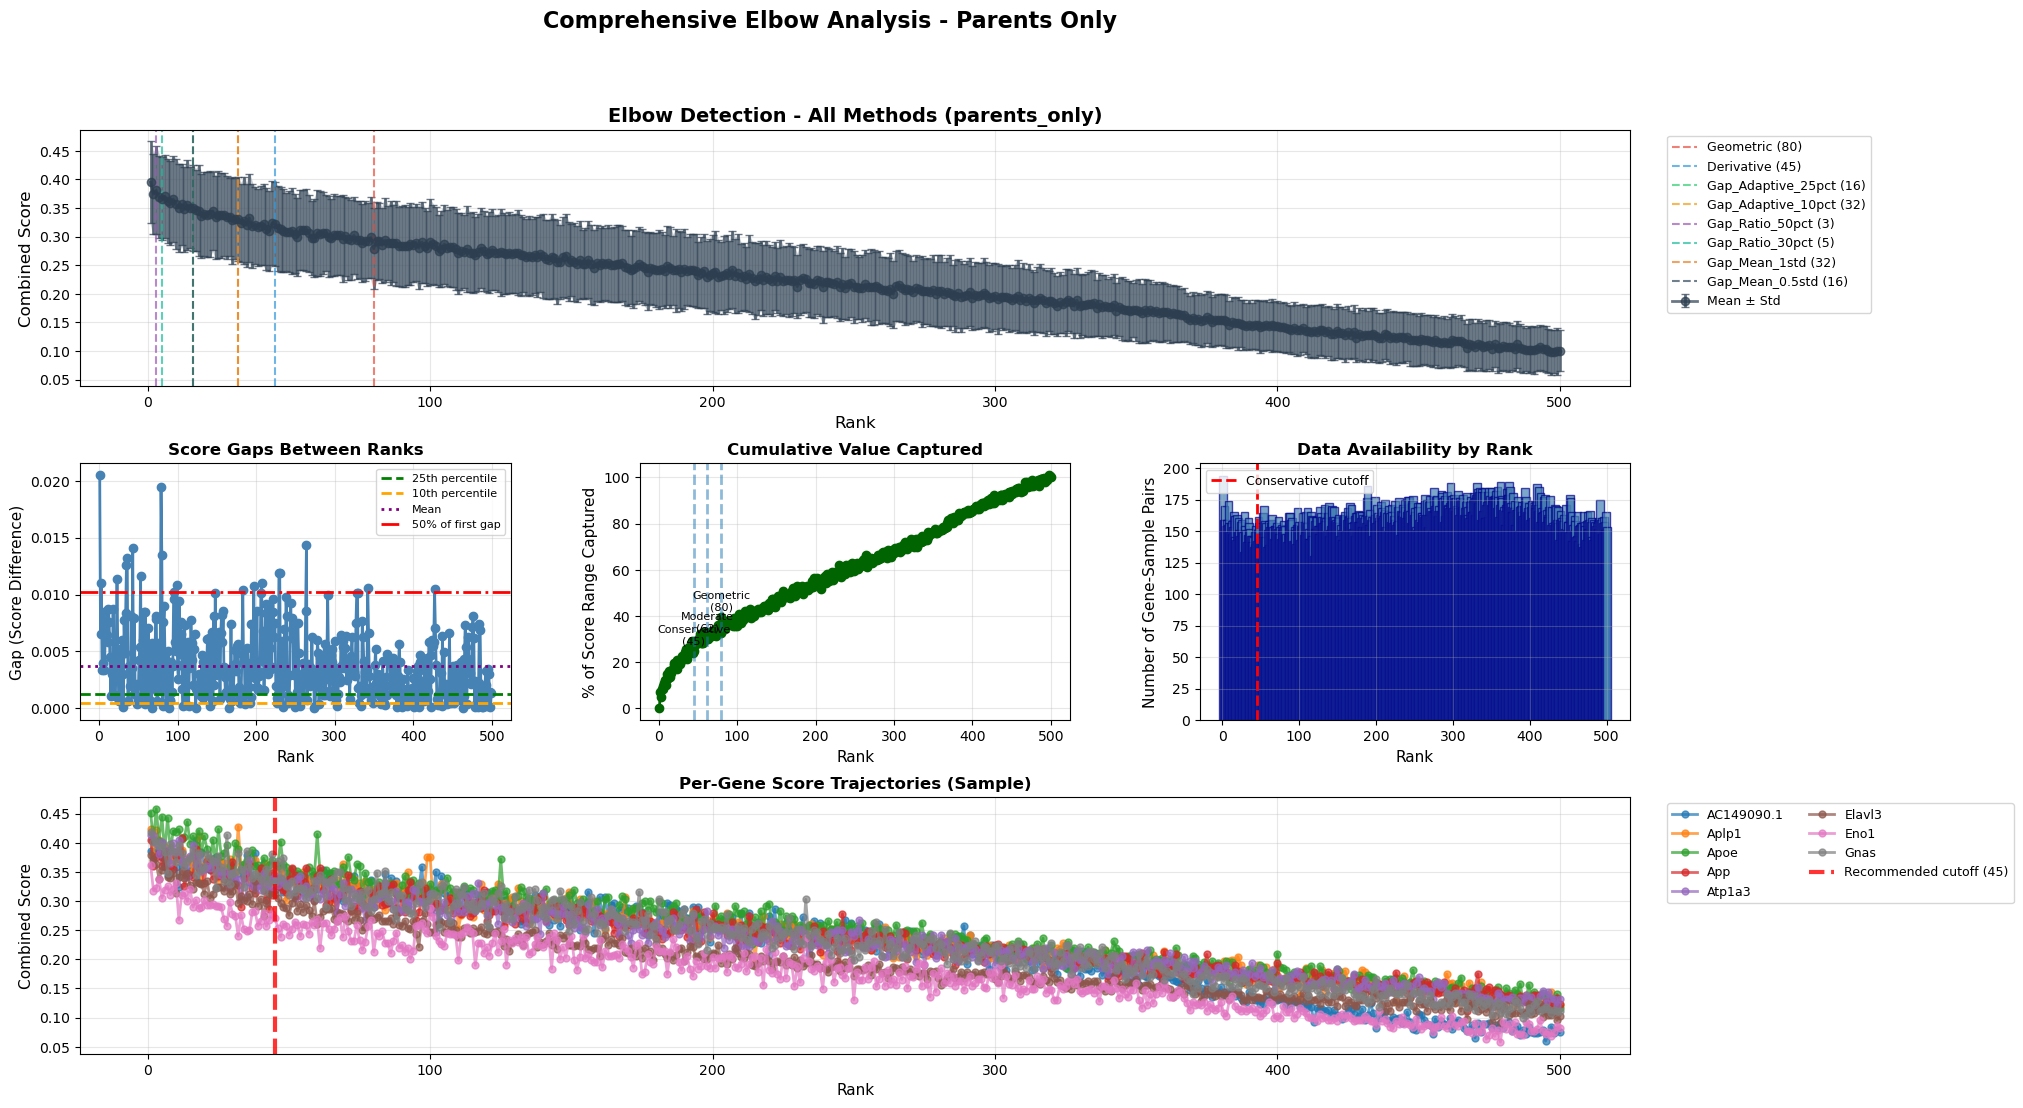


SUMMARY STATISTICS
Total matches after filtering: 81163
Unique genes: 20
Unique samples: 16
Max rank observed: 500

Score statistics:
  Mean: 0.2142
  Std: 0.0913
  Min: 0.0201
  Max: 0.5908


FINAL RECOMMENDATION

Use TOP_K_MATCHES = 45 with 'parents_only' filtering

This captures the most reliable signal while minimizing
computational cost and false positives from isotope/adduct children.

For your pipeline, set:
  TOP_K_MATCHES = 45
  Apply parent filtering after matching
  Focus on ranks 1-45 as high-confidence candidates



In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# =============================================================================
# CONFIGURATION
# =============================================================================
INPUT_FILE = '500_gene_to_mz_synced_results_v1_analytic_fast/gene_to_mz_top500_matches_all_scores.csv'
PARENT_CHILD_FILE = "/home/ajarrah/PhD_Thesis/chapter_4/code_final/2_mz_synced_isotope_80_matching_results/parent_children_hierarchy.csv"
SAVE_DIR = "rank_validation_analysis/"
os.makedirs(SAVE_DIR, exist_ok=True)

# =============================================================================
# PARENT/CHILD FILTERING UTILITIES - CORRECTED
# =============================================================================

def load_parent_child_hierarchy(filepath):
    """
    Load parent-child relationships and create lookup dictionaries.
    Returns:
        - parent_set: Set of all parent m/z values
        - child_set: Set of all child m/z values (these should be filtered out)
        - child_to_parent: Dict mapping child m/z to parent m/z
        - parent_to_children: Dict mapping parent m/z to list of children
    """
    df = pd.read_csv(filepath)
    
    parent_set = set()
    child_set = set()
    child_to_parent = {}
    parent_to_children = {}
    
    for _, row in df.iterrows():
        parent = row['Parent_MZ']
        parent_set.add(parent)
        
        children = []
        for col in ['Child_1', 'Child_2', 'Child_3', 'Child_4', 'Child_5']:
            if pd.notna(row[col]):
                child = row[col]
                children.append(child)
                child_set.add(child)
                child_to_parent[child] = parent
        
        if children:
            parent_to_children[parent] = children
    
    print(f"Loaded hierarchy: {len(parent_set)} parents, {len(child_set)} children")
    return parent_set, child_set, child_to_parent, parent_to_children

def match_mz_to_hierarchy(mz_feature, parent_set, child_set, child_to_parent, tolerance=0.01):
    """
    Match an m/z feature string to parent/child hierarchy.
    
    Args:
        mz_feature: String like "339.2312" or "mz_339.2312"
        parent_set: Set of parent m/z values
        child_set: Set of child m/z values
        child_to_parent: Dict mapping child to parent
        tolerance: Matching tolerance for floating point comparison
    
    Returns:
        - 'parent': It's a parent ion (has children)
        - 'standalone': Not in hierarchy (no children, keep it)
        - 'child': It's a child ion (should be filtered out)
    """
    # Extract numeric m/z value from string
    try:
        mz_str = str(mz_feature).replace('mz_', '').split('_')[0].strip()
        mz_value = float(mz_str)
    except (ValueError, AttributeError):
        return 'standalone'  # Can't parse, assume standalone
    
    # Check if it's a child (these should be filtered out)
    for child in child_set:
        if abs(mz_value - child) <= tolerance:
            return 'child'
    
    # Check if it's a parent (has children listed)
    for parent in parent_set:
        if abs(mz_value - parent) <= tolerance:
            return 'parent'
    
    # Not in hierarchy at all = standalone parent (no children detected)
    return 'standalone'

def filter_to_parents_only(df, parent_set, child_set, child_to_parent, mz_column='mz_feature', tolerance=0.01):
    """
    Filter dataframe to REMOVE ONLY child ions.
    Keep both: (1) parents with children, and (2) standalone m/z with no children.
    
    CORRECTED LOGIC:
    - Keep if m/z is in Parent_MZ column (explicit parent)
    - Keep if m/z is NOT in hierarchy at all (standalone, no children)
    - Remove ONLY if m/z is in Child_1-5 columns (child/isotope/adduct)
    """
    def should_keep(mz_feature):
        result = match_mz_to_hierarchy(mz_feature, parent_set, child_set, child_to_parent, tolerance)
        # Keep parents and standalone, remove only children
        return result in ['parent', 'standalone']
    
    mask = df[mz_column].apply(should_keep)
    n_total = len(df)
    n_kept = mask.sum()
    n_children = n_total - n_kept
    
    # Additional statistics
    def get_category(mz):
        return match_mz_to_hierarchy(mz, parent_set, child_set, child_to_parent, tolerance)
    
    categories = df[mz_column].apply(get_category)
    n_parents = (categories == 'parent').sum()
    n_standalone = (categories == 'standalone').sum()
    n_children_exact = (categories == 'child').sum()
    
    print(f"\nFiltering results:")
    print(f"  Total matches: {n_total}")
    print(f"  Parents (with children): {n_parents} ({n_parents/n_total*100:.1f}%)")
    print(f"  Standalone (no children): {n_standalone} ({n_standalone/n_total*100:.1f}%)")
    print(f"  Children (FILTERED OUT): {n_children_exact} ({n_children_exact/n_total*100:.1f}%)")
    print(f"  Total KEPT: {n_kept} ({n_kept/n_total*100:.1f}%)")
    
    return df[mask].copy()

def aggregate_children_to_parent(df, parent_set, child_set, child_to_parent, mz_column='mz_feature', 
                                  score_column='combined_score', tolerance=0.01):
    """
    Aggregate child matches to their parent, keeping the best score.
    For standalone m/z (not in hierarchy), keep as-is.
    
    CORRECTED LOGIC:
    - Children are aggregated to their parents
    - Standalone m/z (not in hierarchy) are kept as individual entries
    - Parents without matches through children are kept as-is
    """
    df = df.copy()
    
    def get_parent_assignment(mz_feature):
        """Return the parent m/z this feature should be grouped with"""
        result = match_mz_to_hierarchy(mz_feature, parent_set, child_set, child_to_parent, tolerance)
        
        try:
            mz_str = str(mz_feature).replace('mz_', '').split('_')[0].strip()
            mz_value = float(mz_str)
        except:
            return None
        
        if result == 'child':
            # It's a child, map to parent
            for child, parent in child_to_parent.items():
                if abs(mz_value - child) <= tolerance:
                    return parent
        elif result == 'parent':
            # It's a parent, map to itself
            return mz_value
        else:  # standalone
            # Not in hierarchy, map to itself
            return mz_value
        
        return None
    
    df['parent_mz'] = df[mz_column].apply(get_parent_assignment)
    df_valid = df[df['parent_mz'].notna()].copy()
    
    # Group by gene, sample, and parent_mz, keeping best score
    aggregated = df_valid.loc[df_valid.groupby(['gene', 'rna_sample', 'parent_mz'])[score_column].idxmax()]
    
    # Add metadata about aggregation
    child_counts = df_valid.groupby(['gene', 'rna_sample', 'parent_mz']).size()
    aggregated['n_family_members'] = aggregated.apply(
        lambda row: child_counts.get((row['gene'], row['rna_sample'], row['parent_mz']), 1), axis=1
    )
    
    # Count different types
    def get_category(mz):
        return match_mz_to_hierarchy(mz, parent_set, child_set, child_to_parent, tolerance)
    
    original_categories = df[mz_column].apply(get_category)
    
    print(f"\nAggregation results:")
    print(f"  Original matches: {len(df)}")
    print(f"    - Parents: {(original_categories == 'parent').sum()}")
    print(f"    - Standalone: {(original_categories == 'standalone').sum()}")
    print(f"    - Children: {(original_categories == 'child').sum()}")
    print(f"  After aggregation: {len(aggregated)} unique parent/standalone entries")
    print(f"  Average family size: {aggregated['n_family_members'].mean():.2f}")
    
    return aggregated.drop('parent_mz', axis=1)

# =============================================================================
# ELBOW DETECTION FUNCTIONS
# =============================================================================

def find_elbow_geometric(x, y):
    """
    Geometric method: Maximum distance from line connecting first and last points.
    Most robust for general use.
    """
    n_points = len(x)
    first_point = np.array([x[0], y[0]])
    line_vec = np.array([x[-1], y[-1]]) - first_point
    line_vec_norm = line_vec / np.sqrt(np.sum(line_vec**2))
    vec_from_first = np.array([x, y]).T - first_point
    scalar_proj = np.dot(vec_from_first, line_vec_norm)
    vec_proj = np.outer(scalar_proj, line_vec_norm)
    dist_to_line = np.sqrt(np.sum((vec_from_first - vec_proj)**2, axis=1))
    return x[np.argmax(dist_to_line)]

def find_elbow_derivative(x, y):
    """
    Second derivative method: Maximum curvature point.
    Sensitive to local changes in slope.
    """
    dy = np.gradient(y)
    d2y = np.gradient(dy)
    return x[np.argmin(d2y)]

def find_elbow_gap_statistic_adaptive(x, y, percentile=25):
    """
    Adaptive gap statistic: finds where gap drops below the 25th percentile of all gaps.
    More robust to data characteristics than fixed threshold.
    
    Args:
        x: Rank values
        y: Score values
        percentile: Use this percentile of gaps as threshold (default 25 = bottom quartile)
    """
    gaps = np.abs(np.diff(y))
    
    if len(gaps) == 0:
        return x[-1]
    
    # Use percentile of gaps as threshold instead of fixed value
    threshold = np.percentile(gaps, percentile)
    
    # Find first point where gap drops below threshold
    small_gaps = np.where(gaps < threshold)[0]
    if len(small_gaps) > 0:
        return x[small_gaps[0] + 1]
    return x[-1]

def find_elbow_gap_statistic_ratio(x, y, ratio_threshold=0.5):
    """
    Ratio-based gap statistic: finds where gap is less than X% of the first (largest) gap.
    Good for exponential decay patterns.
    
    Args:
        x: Rank values
        y: Score values
        ratio_threshold: Gap must drop below this fraction of first gap (0.5 = 50%)
    """
    gaps = np.abs(np.diff(y))
    
    if len(gaps) == 0:
        return x[-1]
    
    # Compare to first gap (usually largest for good rankings)
    first_gap = gaps[0]
    
    if first_gap == 0:
        return x[0]
    
    # Find where gap becomes small relative to first gap
    small_gaps = np.where(gaps < ratio_threshold * first_gap)[0]
    if len(small_gaps) > 0:
        return x[small_gaps[0] + 1]
    return x[-1]

def find_elbow_gap_statistic_mean(x, y, n_std=1.0):
    """
    Statistical gap method: finds where gap drops below mean - n*std.
    Good for noisy data with variable gaps.
    
    Args:
        x: Rank values
        y: Score values  
        n_std: Number of standard deviations below mean (default 1.0)
    """
    gaps = np.abs(np.diff(y))
    
    if len(gaps) == 0:
        return x[-1]
    
    mean_gap = np.mean(gaps)
    std_gap = np.std(gaps)
    threshold = mean_gap - n_std * std_gap
    
    # Don't let threshold go negative
    threshold = max(threshold, 0)
    
    # Find first point where gap drops below threshold
    small_gaps = np.where(gaps < threshold)[0]
    if len(small_gaps) > 0:
        return x[small_gaps[0] + 1]
    return x[-1]

def get_final_recommendation(methods_dict, strategy='conservative'):
    """
    Get final recommendation based on multiple methods.
    
    Args:
        methods_dict: Dict of method names to elbow ranks
        strategy: 'conservative' (min of geometric/derivative), 
                  'moderate' (median of geometric/derivative),
                  'geometric_only' (trust geometric most)
    """
    geometric = methods_dict.get('Geometric')
    derivative = methods_dict.get('Derivative')
    
    if strategy == 'conservative':
        # Use minimum of geometric and derivative (gap methods excluded as too aggressive)
        return int(min(geometric, derivative))
    
    elif strategy == 'moderate':
        # Use median of geometric and derivative
        return int(np.median([geometric, derivative]))
    
    else:  # 'geometric_only'
        # Trust geometric method most (most robust)
        return int(geometric)

# =============================================================================
# COMPREHENSIVE ANALYSIS WITH MULTIPLE GAP METHODS
# =============================================================================

def run_comprehensive_analysis_enhanced(file_path, parent_child_path, filter_mode='parents_only'):
    """
    Run comprehensive rank analysis with all elbow detection methods.
    """
    # 1. Load data
    try:
        df = pd.read_csv(file_path)
        print(f"Loaded {len(df)} matches from {file_path}")
    except FileNotFoundError:
        print(f"Error: File {file_path} not found.")
        return None, None, None
    
    # 2. Load parent-child hierarchy
    try:
        parent_set, child_set, child_to_parent, parent_to_children = load_parent_child_hierarchy(parent_child_path)
    except FileNotFoundError:
        print(f"Error: Hierarchy file {parent_child_path} not found.")
        return None, None, None
    
    # 3. Apply filtering
    print(f"\n{'='*70}")
    print(f"FILTERING MODE: {filter_mode.upper()}")
    print(f"{'='*70}")
    
    if filter_mode == 'parents_only':
        df_filtered = filter_to_parents_only(df, parent_set, child_set, child_to_parent)
    elif filter_mode == 'aggregate':
        df_filtered = aggregate_children_to_parent(df, parent_set, child_set, child_to_parent)
    else:
        df_filtered = df.copy()
        print("No filtering applied (using all matches)")
    
    # Save filtered results
    filtered_path = os.path.join(SAVE_DIR, f'filtered_matches_{filter_mode}.csv')
    df_filtered.to_csv(filtered_path, index=False)
    print(f"\nFiltered results saved to: {filtered_path}")
    
    # 4. Re-rank if necessary
    if 'rank' not in df_filtered.columns:
        print("\nRe-ranking matches after filtering...")
        df_filtered = df_filtered.sort_values(['gene', 'rna_sample', 'combined_score'], 
                                                ascending=[True, True, False])
        df_filtered['rank'] = df_filtered.groupby(['gene', 'rna_sample']).cumcount() + 1
    
    # 5. Compute rank statistics
    rank_stats = df_filtered.groupby('rank').agg({
        'combined_score': ['mean', 'std', 'median', 'min', 'max', 'count']
    }).reset_index()
    rank_stats.columns = ['rank', 'mean_score', 'std_score', 'median_score', 
                          'min_score', 'max_score', 'count']
    
    ranks = rank_stats['rank'].values
    mean_scores = rank_stats['mean_score'].values
    std_scores = rank_stats['std_score'].values
    counts = rank_stats['count'].values
    
    # 6. Calculate ALL elbow detection methods
    print(f"\n{'='*70}")
    print("ELBOW DETECTION RESULTS (Multiple Methods)")
    print(f"{'='*70}")
    
    methods = {
        'Geometric': find_elbow_geometric(ranks, mean_scores),
        'Derivative': find_elbow_derivative(ranks, mean_scores),
        'Gap_Adaptive_25pct': find_elbow_gap_statistic_adaptive(ranks, mean_scores, percentile=25),
        'Gap_Adaptive_10pct': find_elbow_gap_statistic_adaptive(ranks, mean_scores, percentile=10),
        'Gap_Ratio_50pct': find_elbow_gap_statistic_ratio(ranks, mean_scores, ratio_threshold=0.5),
        'Gap_Ratio_30pct': find_elbow_gap_statistic_ratio(ranks, mean_scores, ratio_threshold=0.3),
        'Gap_Mean_1std': find_elbow_gap_statistic_mean(ranks, mean_scores, n_std=1.0),
        'Gap_Mean_0.5std': find_elbow_gap_statistic_mean(ranks, mean_scores, n_std=0.5)
    }
    
    # Print results
    print(f"\n{'Method':<25} {'Elbow Rank':>15}")
    print("-"*70)
    for method, rank in methods.items():
        print(f"{method:<25} {rank:>15}")
    
    # 7. Get recommendations
    recommendations = {
        'Conservative (min of Geo/Der)': get_final_recommendation(methods, 'conservative'),
        'Moderate (median of Geo/Der)': get_final_recommendation(methods, 'moderate'),
        'Geometric Only': get_final_recommendation(methods, 'geometric_only')
    }
    
    print(f"\n{'='*70}")
    print("RECOMMENDATIONS")
    print(f"{'='*70}")
    for strategy, rank in recommendations.items():
        print(f"{strategy:<30} {rank:>15}")
    
    # 8. Visualization
    fig = plt.figure(figsize=(20, 12))
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)
    
    # Plot 1: Main score plot with all methods
    ax1 = fig.add_subplot(gs[0, :])
    ax1.errorbar(ranks, mean_scores, yerr=std_scores, fmt='o-', color='#2c3e50',
                 label='Mean ± Std', linewidth=2, markersize=6, capsize=3, alpha=0.7)
    ax1.fill_between(ranks, mean_scores - std_scores, mean_scores + std_scores,
                     alpha=0.2, color='#2c3e50')
    
    # Plot method lines
    colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c', '#e67e22', '#34495e']
    for (method, rank), color in zip(methods.items(), colors):
        ax1.axvline(x=rank, color=color, linestyle='--', alpha=0.7, linewidth=1.5, label=f'{method} ({rank})')
    
    ax1.set_title(f'Elbow Detection - All Methods ({filter_mode})', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Rank', fontsize=12)
    ax1.set_ylabel('Combined Score', fontsize=12)
    ax1.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
    ax1.grid(alpha=0.3)
    
    # Plot 2: Gap analysis
    ax2 = fig.add_subplot(gs[1, 0])
    gaps = np.abs(np.diff(mean_scores))
    gap_ranks = ranks[:-1]
    ax2.plot(gap_ranks, gaps, 'o-', color='steelblue', linewidth=2, markersize=6)
    
    # Show thresholds
    max_gap = gaps.max()
    ax2.axhline(y=np.percentile(gaps, 25), color='green', linestyle='--', 
                label=f'25th percentile', linewidth=2)
    ax2.axhline(y=np.percentile(gaps, 10), color='orange', linestyle='--',
                label=f'10th percentile', linewidth=2)
    ax2.axhline(y=np.mean(gaps), color='purple', linestyle=':',
                label=f'Mean', linewidth=2)
    if len(gaps) > 0 and gaps[0] > 0:
        ax2.axhline(y=gaps[0] * 0.5, color='red', linestyle='-.',
                    label=f'50% of first gap', linewidth=2)
    
    ax2.set_xlabel('Rank', fontsize=11)
    ax2.set_ylabel('Gap (Score Difference)', fontsize=11)
    ax2.set_title('Score Gaps Between Ranks', fontsize=12, fontweight='bold')
    ax2.legend(fontsize=8)
    ax2.grid(alpha=0.3)
    
    # Plot 3: Cumulative value captured
    ax3 = fig.add_subplot(gs[1, 1])
    score_range = mean_scores[0] - mean_scores[-1]
    if score_range > 0:
        cumulative_capture = (mean_scores[0] - mean_scores) / score_range * 100
    else:
        cumulative_capture = np.zeros_like(mean_scores)
    
    ax3.plot(ranks, cumulative_capture, 'o-', color='darkgreen', linewidth=2, markersize=6)
    
    # Mark key recommendations
    for strategy, rank in recommendations.items():
        if rank <= max(ranks):
            idx = np.where(ranks == rank)[0]
            if len(idx) > 0:
                capture = cumulative_capture[idx[0]]
                ax3.axvline(x=rank, alpha=0.5, linestyle='--', linewidth=2)
                ax3.text(rank, capture + 3, f'{strategy.split()[0]}\n({rank})', 
                        rotation=0, fontsize=8, ha='center')
    
    ax3.set_xlabel('Rank', fontsize=11)
    ax3.set_ylabel('% of Score Range Captured', fontsize=11)
    ax3.set_title('Cumulative Value Captured', fontsize=12, fontweight='bold')
    ax3.grid(alpha=0.3)
    
    # Plot 4: Data availability
    ax4 = fig.add_subplot(gs[1, 2])
    ax4.bar(ranks, counts, color='steelblue', alpha=0.7, edgecolor='darkblue', width=max(ranks)*0.02)
    ax4.axvline(x=recommendations['Conservative (min of Geo/Der)'], color='red', 
                linestyle='--', linewidth=2, label='Conservative cutoff')
    ax4.set_xlabel('Rank', fontsize=11)
    ax4.set_ylabel('Number of Gene-Sample Pairs', fontsize=11)
    ax4.set_title('Data Availability by Rank', fontsize=12, fontweight='bold')
    ax4.legend(fontsize=9)
    ax4.grid(alpha=0.3)
    
    # Plot 5: Per-gene sample (first 8 genes)
    ax5 = fig.add_subplot(gs[2, :])
    genes_to_plot = df_filtered['gene'].unique()[:8]
    for i, gene in enumerate(genes_to_plot):
        gene_df = df_filtered[df_filtered['gene'] == gene].sort_values('rank')
        gene_rank_avg = gene_df.groupby('rank')['combined_score'].mean()
        ax5.plot(gene_rank_avg.index, gene_rank_avg.values, 'o-', 
                alpha=0.7, label=gene, markersize=5, linewidth=2)
    
    ax5.axvline(x=recommendations['Conservative (min of Geo/Der)'], color='red', 
                linestyle='--', linewidth=3, alpha=0.8, label=f"Recommended cutoff ({recommendations['Conservative (min of Geo/Der)']})")
    ax5.set_xlabel('Rank', fontsize=11)
    ax5.set_ylabel('Combined Score', fontsize=11)
    ax5.set_title('Per-Gene Score Trajectories (Sample)', fontsize=12, fontweight='bold')
    ax5.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9, ncol=2)
    ax5.grid(alpha=0.3)
    
    plt.suptitle(f'Comprehensive Elbow Analysis - {filter_mode.replace("_", " ").title()}', 
                 fontsize=16, fontweight='bold')
    
    plot_path = os.path.join(SAVE_DIR, f'comprehensive_analysis_{filter_mode}.png')
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    print(f"\nPlot saved to: {plot_path}")
    plt.show()
    
    # 9. Summary statistics
    print(f"\n{'='*70}")
    print("SUMMARY STATISTICS")
    print(f"{'='*70}")
    print(f"Total matches after filtering: {len(df_filtered)}")
    print(f"Unique genes: {df_filtered['gene'].nunique()}")
    print(f"Unique samples: {df_filtered['rna_sample'].nunique()}")
    print(f"Max rank observed: {df_filtered['rank'].max()}")
    print(f"\nScore statistics:")
    print(f"  Mean: {df_filtered['combined_score'].mean():.4f}")
    print(f"  Std: {df_filtered['combined_score'].std():.4f}")
    print(f"  Min: {df_filtered['combined_score'].min():.4f}")
    print(f"  Max: {df_filtered['combined_score'].max():.4f}")
    print(f"{'='*70}\n")
    
    return df_filtered, methods, recommendations

# =============================================================================
# MAIN EXECUTION
# =============================================================================

if __name__ == "__main__":
    print("="*70)
    print("ENHANCED GENE-TO-M/Z RANK ANALYSIS")
    print("Multiple Elbow Detection Methods with Parent/Child Filtering")
    print("="*70)
    
    # Analyze with parent filtering (recommended)
    print("\n\n" + "="*70)
    print("ANALYSIS: PARENTS ONLY (Recommended)")
    print("="*70)
    df_parents, methods_parents, rec_parents = run_comprehensive_analysis_enhanced(
        INPUT_FILE, PARENT_CHILD_FILE, filter_mode='parents_only'
    )
    
    # Optionally run other modes for comparison
    run_other_modes = input("\nRun aggregate and no-filter modes for comparison? (y/n): ").lower() == 'y'
    
    if run_other_modes:
        print("\n\n" + "="*70)
        print("ANALYSIS: AGGREGATE MODE")
        print("="*70)
        df_aggregate, methods_aggregate, rec_aggregate = run_comprehensive_analysis_enhanced(
            INPUT_FILE, PARENT_CHILD_FILE, filter_mode='aggregate'
        )
        
        print("\n\n" + "="*70)
        print("ANALYSIS: NO FILTERING")
        print("="*70)
        df_none, methods_none, rec_none = run_comprehensive_analysis_enhanced(
            INPUT_FILE, PARENT_CHILD_FILE, filter_mode='none'
        )
        
        # Final comparative summary
        print("\n\n" + "="*70)
        print("FINAL COMPARATIVE SUMMARY")
        print("="*70)
        print(f"\n{'Filtering Mode':<20} {'Geometric':<12} {'Derivative':<12} {'Conservative':<15} {'Total Matches':<15}")
        print("-"*80)
        print(f"{'Parents Only':<20} {methods_parents['Geometric']:<12} {methods_parents['Derivative']:<12} "
              f"{rec_parents['Conservative (min of Geo/Der)']:<15} {len(df_parents):<15}")
        print(f"{'Aggregate':<20} {methods_aggregate['Geometric']:<12} {methods_aggregate['Derivative']:<12} "
              f"{rec_aggregate['Conservative (min of Geo/Der)']:<15} {len(df_aggregate):<15}")
        print(f"{'No Filtering':<20} {methods_none['Geometric']:<12} {methods_none['Derivative']:<12} "
              f"{rec_none['Conservative (min of Geo/Der)']:<15} {len(df_none):<15}")
        print("="*70)
    
    # Final recommendation
    print(f"\n{'='*70}")
    print("FINAL RECOMMENDATION")
    print(f"{'='*70}")
    if df_parents is not None:
        final_rec = rec_parents['Conservative (min of Geo/Der)']
        print(f"\nUse TOP_K_MATCHES = {final_rec} with 'parents_only' filtering")
        print(f"\nThis captures the most reliable signal while minimizing")
        print(f"computational cost and false positives from isotope/adduct children.")
        print(f"\nFor your pipeline, set:")
        print(f"  TOP_K_MATCHES = {final_rec}")
        print(f"  Apply parent filtering after matching")
        print(f"  Focus on ranks 1-{final_rec} as high-confidence candidates")
    print(f"{'='*70}\n")

GENE-TO-M/Z RANK ANALYSIS - INDEPENDENT m/z APPROACH

Treating all m/z values as independent molecular species.
No parent-child filtering or relationships considered.
Loaded 160000 matches from 500_gene_to_mz_synced_results_v1_analytic_fast/gene_to_mz_top500_matches_all_scores.csv

ANALYSIS MODE: INDEPENDENT m/z IONS
Treating all m/z values as independent molecular species.
No parent-child filtering applied.

Dataset overview:
  Total matches: 160000
  Unique genes: 20
  Unique samples: 16
  Unique m/z features: 528
  Rank range: 1 to 500

ELBOW DETECTION RESULTS (Multiple Methods)

Method                         Elbow Rank
----------------------------------------------------------------------
Geometric                              78
Derivative                            366
Gap_Fixed_3pct                        500
Gap_Fixed_5pct                        111
Gap_Adaptive_25pct                    143
Gap_Adaptive_10pct                    187
Gap_Ratio_50pct                         4
Gap

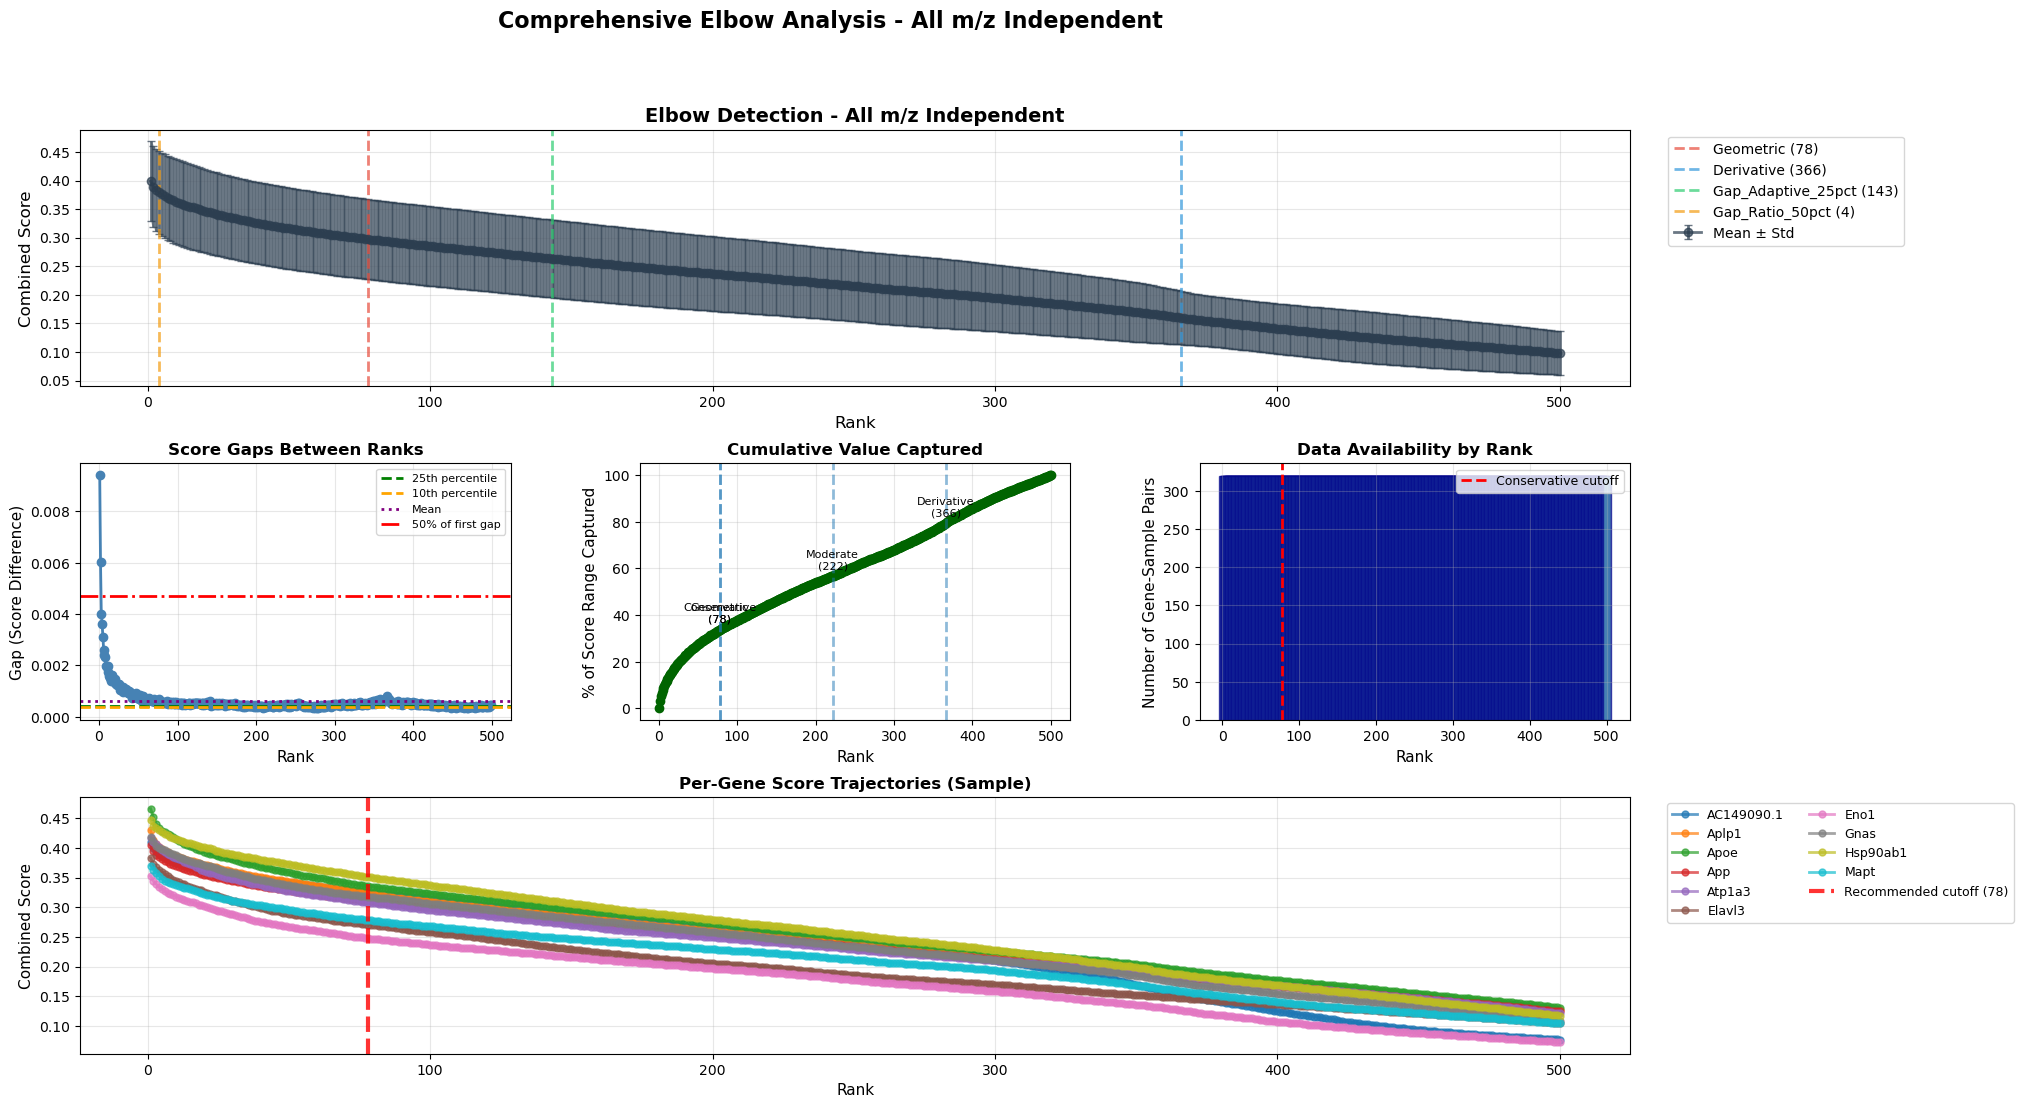


SUMMARY STATISTICS
Total matches: 160000
Unique genes: 20
Unique samples: 16
Unique m/z features: 528
Max rank observed: 500

Score statistics:
  Mean: 0.2169
  Std: 0.0940
  Min: 0.0200
  Max: 0.5908

PER-GENE ELBOW POINTS

Gene            Geometric    Derivative   Conservative   
----------------------------------------------------------------------
AC149090.1      42           342          42             
Aplp1           91           33           33             
Apoe            73           500          73             
App             84           17           17             
Atp1a3          79           11           11             
Elavl3          152          25           25             
Eno1            78           31           31             
Gnas            65           1            1              
Hsp90ab1        76           22           22             
Mapt            74           16           16             
Meg3            57           366          57             
Pkm    

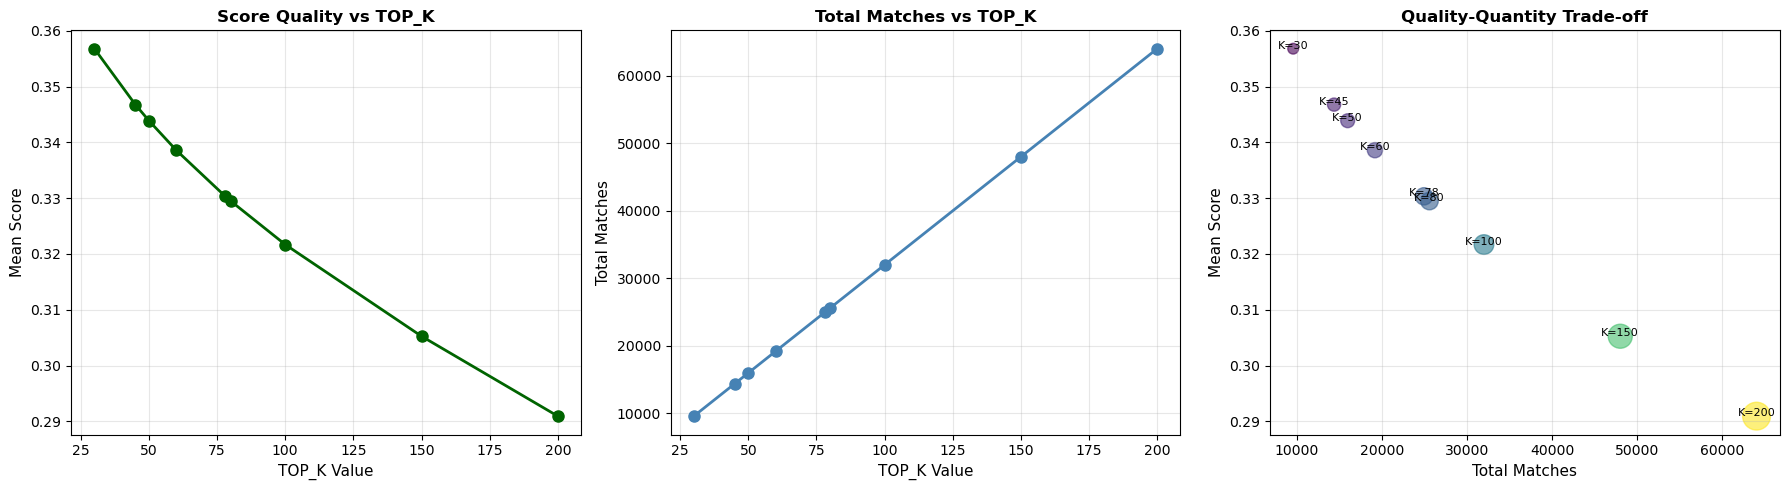


ANALYSIS COMPLETE

Key Findings:
  - Geometric elbow: 78
  - Derivative elbow: 366
  - Conservative recommendation: 78

All results saved to: rank_validation_analysis_independent/



In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# =============================================================================
# CONFIGURATION
# =============================================================================
INPUT_FILE = '500_gene_to_mz_synced_results_v1_analytic_fast/gene_to_mz_top500_matches_all_scores.csv'
SAVE_DIR = "rank_validation_analysis_independent/"
os.makedirs(SAVE_DIR, exist_ok=True)

# =============================================================================
# ELBOW DETECTION FUNCTIONS
# =============================================================================

def find_elbow_geometric(x, y):
    """
    Geometric method: Maximum distance from line connecting first and last points.
    Most robust for general use.
    """
    n_points = len(x)
    first_point = np.array([x[0], y[0]])
    line_vec = np.array([x[-1], y[-1]]) - first_point
    line_vec_norm = line_vec / np.sqrt(np.sum(line_vec**2))
    vec_from_first = np.array([x, y]).T - first_point
    scalar_proj = np.dot(vec_from_first, line_vec_norm)
    vec_proj = np.outer(scalar_proj, line_vec_norm)
    dist_to_line = np.sqrt(np.sum((vec_from_first - vec_proj)**2, axis=1))
    return x[np.argmax(dist_to_line)]

def find_elbow_derivative(x, y):
    """
    Second derivative method: Maximum curvature point.
    Sensitive to local changes in slope.
    """
    dy = np.gradient(y)
    d2y = np.gradient(dy)
    return x[np.argmin(d2y)]

def find_elbow_gap_statistic(x, y, threshold=0.05):
    """
    Gap statistic: Finds elbow where gap between consecutive points becomes small.
    """
    gaps = np.abs(np.diff(y))
    if len(gaps) == 0:
        return x[-1]
    gaps_norm = gaps / (gaps.max() + 1e-10)
    small_gaps = np.where(gaps_norm < threshold)[0]
    if len(small_gaps) > 0:
        return x[small_gaps[0] + 1]
    return x[-1]

def find_elbow_gap_adaptive(x, y, percentile=25):
    """
    Adaptive gap statistic: Uses percentile of gaps as threshold.
    More robust to data characteristics than fixed threshold.
    """
    gaps = np.abs(np.diff(y))
    if len(gaps) == 0:
        return x[-1]
    threshold = np.percentile(gaps, percentile)
    small_gaps = np.where(gaps < threshold)[0]
    if len(small_gaps) > 0:
        return x[small_gaps[0] + 1]
    return x[-1]

def find_elbow_gap_ratio(x, y, ratio_threshold=0.5):
    """
    Ratio-based gap statistic: Gap relative to first gap.
    Good for exponential decay patterns.
    """
    gaps = np.abs(np.diff(y))
    if len(gaps) == 0:
        return x[-1]
    first_gap = gaps[0]
    if first_gap == 0:
        return x[0]
    small_gaps = np.where(gaps < ratio_threshold * first_gap)[0]
    if len(small_gaps) > 0:
        return x[small_gaps[0] + 1]
    return x[-1]

def find_elbow_gap_mean(x, y, n_std=1.0):
    """
    Statistical gap method: Gap below mean - n*std.
    Good for noisy data with variable gaps.
    """
    gaps = np.abs(np.diff(y))
    if len(gaps) == 0:
        return x[-1]
    mean_gap = np.mean(gaps)
    std_gap = np.std(gaps)
    threshold = mean_gap - n_std * std_gap
    threshold = max(threshold, 0)
    small_gaps = np.where(gaps < threshold)[0]
    if len(small_gaps) > 0:
        return x[small_gaps[0] + 1]
    return x[-1]

# =============================================================================
# COMPREHENSIVE ANALYSIS - INDEPENDENT m/z
# =============================================================================

def run_comprehensive_analysis_independent(file_path):
    """
    Run comprehensive rank analysis treating each m/z as independent.
    No parent-child filtering applied.
    
    Args:
        file_path: Path to match results CSV
    """
    # 1. Load data
    try:
        df = pd.read_csv(file_path)
        print(f"Loaded {len(df)} matches from {file_path}")
    except FileNotFoundError:
        print(f"Error: File {file_path} not found.")
        return None, None, None
    
    print(f"\n{'='*70}")
    print(f"ANALYSIS MODE: INDEPENDENT m/z IONS")
    print(f"{'='*70}")
    print("Treating all m/z values as independent molecular species.")
    print("No parent-child filtering applied.")
    
    # 2. Basic statistics
    print(f"\nDataset overview:")
    print(f"  Total matches: {len(df)}")
    print(f"  Unique genes: {df['gene'].nunique()}")
    print(f"  Unique samples: {df['rna_sample'].nunique()}")
    print(f"  Unique m/z features: {df['mz_feature'].nunique()}")
    print(f"  Rank range: {df['rank'].min()} to {df['rank'].max()}")
    
    # 3. Compute rank statistics
    rank_stats = df.groupby('rank').agg({
        'combined_score': ['mean', 'std', 'median', 'min', 'max', 'count']
    }).reset_index()
    rank_stats.columns = ['rank', 'mean_score', 'std_score', 'median_score', 
                          'min_score', 'max_score', 'count']
    
    ranks = rank_stats['rank'].values
    mean_scores = rank_stats['mean_score'].values
    std_scores = rank_stats['std_score'].values
    counts = rank_stats['count'].values
    
    # 4. Calculate ALL elbow detection methods
    print(f"\n{'='*70}")
    print("ELBOW DETECTION RESULTS (Multiple Methods)")
    print(f"{'='*70}")
    
    methods = {
        'Geometric': find_elbow_geometric(ranks, mean_scores),
        'Derivative': find_elbow_derivative(ranks, mean_scores),
        'Gap_Fixed_3pct': find_elbow_gap_statistic(ranks, mean_scores, threshold=0.03),
        'Gap_Fixed_5pct': find_elbow_gap_statistic(ranks, mean_scores, threshold=0.05),
        'Gap_Adaptive_25pct': find_elbow_gap_adaptive(ranks, mean_scores, percentile=25),
        'Gap_Adaptive_10pct': find_elbow_gap_adaptive(ranks, mean_scores, percentile=10),
        'Gap_Ratio_50pct': find_elbow_gap_ratio(ranks, mean_scores, ratio_threshold=0.5),
        'Gap_Ratio_30pct': find_elbow_gap_ratio(ranks, mean_scores, ratio_threshold=0.3),
        'Gap_Mean_1std': find_elbow_gap_mean(ranks, mean_scores, n_std=1.0),
        'Gap_Mean_0.5std': find_elbow_gap_mean(ranks, mean_scores, n_std=0.5)
    }
    
    # Print results
    print(f"\n{'Method':<25} {'Elbow Rank':>15}")
    print("-"*70)
    for method, rank in methods.items():
        print(f"{method:<25} {rank:>15}")
    
    # 5. Get recommendations
    recommendations = {
        'Conservative (min Geo/Der)': int(min(methods['Geometric'], methods['Derivative'])),
        'Moderate (median Geo/Der)': int(np.median([methods['Geometric'], methods['Derivative']])),
        'Geometric Only': int(methods['Geometric']),
        'Derivative Only': int(methods['Derivative'])
    }
    
    print(f"\n{'='*70}")
    print("RECOMMENDATIONS")
    print(f"{'='*70}")
    for strategy, rank in recommendations.items():
        print(f"{strategy:<30} {rank:>15}")
    
    # 6. Visualization
    fig = plt.figure(figsize=(20, 12))
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)
    
    # Plot 1: Main score plot with all methods
    ax1 = fig.add_subplot(gs[0, :])
    ax1.errorbar(ranks, mean_scores, yerr=std_scores, fmt='o-', color='#2c3e50',
                 label='Mean ± Std', linewidth=2, markersize=6, capsize=3, alpha=0.7)
    ax1.fill_between(ranks, mean_scores - std_scores, mean_scores + std_scores,
                     alpha=0.2, color='#2c3e50')
    
    # Plot key method lines
    colors = {'Geometric': '#e74c3c', 'Derivative': '#3498db', 
              'Gap_Adaptive_25pct': '#2ecc71', 'Gap_Ratio_50pct': '#f39c12'}
    for method, color in colors.items():
        rank = methods[method]
        ax1.axvline(x=rank, color=color, linestyle='--', alpha=0.7, linewidth=2, 
                   label=f'{method} ({rank})')
    
    ax1.set_title('Elbow Detection - All m/z Independent', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Rank', fontsize=12)
    ax1.set_ylabel('Combined Score', fontsize=12)
    ax1.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
    ax1.grid(alpha=0.3)
    
    # Plot 2: Gap analysis
    ax2 = fig.add_subplot(gs[1, 0])
    gaps = np.abs(np.diff(mean_scores))
    gap_ranks = ranks[:-1]
    ax2.plot(gap_ranks, gaps, 'o-', color='steelblue', linewidth=2, markersize=6)
    
    # Show thresholds
    ax2.axhline(y=np.percentile(gaps, 25), color='green', linestyle='--', 
                label=f'25th percentile', linewidth=2)
    ax2.axhline(y=np.percentile(gaps, 10), color='orange', linestyle='--',
                label=f'10th percentile', linewidth=2)
    ax2.axhline(y=np.mean(gaps), color='purple', linestyle=':',
                label=f'Mean', linewidth=2)
    if len(gaps) > 0 and gaps[0] > 0:
        ax2.axhline(y=gaps[0] * 0.5, color='red', linestyle='-.',
                    label=f'50% of first gap', linewidth=2)
    
    ax2.set_xlabel('Rank', fontsize=11)
    ax2.set_ylabel('Gap (Score Difference)', fontsize=11)
    ax2.set_title('Score Gaps Between Ranks', fontsize=12, fontweight='bold')
    ax2.legend(fontsize=8)
    ax2.grid(alpha=0.3)
    
    # Plot 3: Cumulative value captured
    ax3 = fig.add_subplot(gs[1, 1])
    score_range = mean_scores[0] - mean_scores[-1]
    if score_range > 0:
        cumulative_capture = (mean_scores[0] - mean_scores) / score_range * 100
    else:
        cumulative_capture = np.zeros_like(mean_scores)
    
    ax3.plot(ranks, cumulative_capture, 'o-', color='darkgreen', linewidth=2, markersize=6)
    
    # Mark key recommendations
    for strategy, rank in recommendations.items():
        if rank <= max(ranks):
            idx = np.where(ranks == rank)[0]
            if len(idx) > 0:
                capture = cumulative_capture[idx[0]]
                ax3.axvline(x=rank, alpha=0.5, linestyle='--', linewidth=2)
                ax3.text(rank, capture + 3, f'{strategy.split()[0]}\n({rank})', 
                        rotation=0, fontsize=8, ha='center')
    
    ax3.set_xlabel('Rank', fontsize=11)
    ax3.set_ylabel('% of Score Range Captured', fontsize=11)
    ax3.set_title('Cumulative Value Captured', fontsize=12, fontweight='bold')
    ax3.grid(alpha=0.3)
    
    # Plot 4: Data availability
    ax4 = fig.add_subplot(gs[1, 2])
    ax4.bar(ranks, counts, color='steelblue', alpha=0.7, edgecolor='darkblue', 
            width=max(ranks)*0.02)
    ax4.axvline(x=recommendations['Conservative (min Geo/Der)'], color='red', 
                linestyle='--', linewidth=2, label='Conservative cutoff')
    ax4.set_xlabel('Rank', fontsize=11)
    ax4.set_ylabel('Number of Gene-Sample Pairs', fontsize=11)
    ax4.set_title('Data Availability by Rank', fontsize=12, fontweight='bold')
    ax4.legend(fontsize=9)
    ax4.grid(alpha=0.3)
    
    # Plot 5: Per-gene sample (first 10 genes)
    ax5 = fig.add_subplot(gs[2, :])
    genes_to_plot = df['gene'].unique()[:10]
    for i, gene in enumerate(genes_to_plot):
        gene_df = df[df['gene'] == gene].sort_values('rank')
        gene_rank_avg = gene_df.groupby('rank')['combined_score'].mean()
        ax5.plot(gene_rank_avg.index, gene_rank_avg.values, 'o-', 
                alpha=0.7, label=gene, markersize=5, linewidth=2)
    
    ax5.axvline(x=recommendations['Conservative (min Geo/Der)'], color='red', 
                linestyle='--', linewidth=3, alpha=0.8, 
                label=f"Recommended cutoff ({recommendations['Conservative (min Geo/Der)']})")
    ax5.set_xlabel('Rank', fontsize=11)
    ax5.set_ylabel('Combined Score', fontsize=11)
    ax5.set_title('Per-Gene Score Trajectories (Sample)', fontsize=12, fontweight='bold')
    ax5.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9, ncol=2)
    ax5.grid(alpha=0.3)
    
    plt.suptitle('Comprehensive Elbow Analysis - All m/z Independent', 
                 fontsize=16, fontweight='bold')
    
    plot_path = os.path.join(SAVE_DIR, 'rank_analysis_independent_mz.png')
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    print(f"\nPlot saved to: {plot_path}")
    plt.show()
    
    # 7. Summary statistics
    print(f"\n{'='*70}")
    print("SUMMARY STATISTICS")
    print(f"{'='*70}")
    print(f"Total matches: {len(df)}")
    print(f"Unique genes: {df['gene'].nunique()}")
    print(f"Unique samples: {df['rna_sample'].nunique()}")
    print(f"Unique m/z features: {df['mz_feature'].nunique()}")
    print(f"Max rank observed: {df['rank'].max()}")
    print(f"\nScore statistics:")
    print(f"  Mean: {df['combined_score'].mean():.4f}")
    print(f"  Std: {df['combined_score'].std():.4f}")
    print(f"  Min: {df['combined_score'].min():.4f}")
    print(f"  Max: {df['combined_score'].max():.4f}")
    
    # 8. Per-gene statistics
    print(f"\n{'='*70}")
    print("PER-GENE ELBOW POINTS")
    print(f"{'='*70}")
    
    gene_elbows = []
    for gene in df['gene'].unique():
        gene_df = df[df['gene'] == gene]
        gene_rank_stats = gene_df.groupby('rank')['combined_score'].mean().reset_index()
        
        if len(gene_rank_stats) >= 3:
            ranks_g = gene_rank_stats['rank'].values
            scores_g = gene_rank_stats['combined_score'].values
            
            elbow_g = find_elbow_geometric(ranks_g, scores_g)
            elbow_d = find_elbow_derivative(ranks_g, scores_g)
            
            gene_elbows.append({
                'gene': gene,
                'geometric_elbow': elbow_g,
                'derivative_elbow': elbow_d,
                'conservative_elbow': min(elbow_g, elbow_d)
            })
    
    gene_elbows_df = pd.DataFrame(gene_elbows)
    print(f"\n{'Gene':<15} {'Geometric':<12} {'Derivative':<12} {'Conservative':<15}")
    print("-"*70)
    for _, row in gene_elbows_df.iterrows():
        print(f"{row['gene']:<15} {row['geometric_elbow']:<12.0f} "
              f"{row['derivative_elbow']:<12.0f} {row['conservative_elbow']:<15.0f}")
    
    print(f"\nMedian elbow across genes: {gene_elbows_df['conservative_elbow'].median():.0f}")
    print(f"Mean elbow across genes: {gene_elbows_df['conservative_elbow'].mean():.1f}")
    
    # Save results
    results_path = os.path.join(SAVE_DIR, 'independent_mz_analysis_results.csv')
    rank_stats.to_csv(results_path, index=False)
    
    gene_elbows_path = os.path.join(SAVE_DIR, 'per_gene_elbows_independent.csv')
    gene_elbows_df.to_csv(gene_elbows_path, index=False)
    
    print(f"\nResults saved to:")
    print(f"  {results_path}")
    print(f"  {gene_elbows_path}")
    
    # 9. Final recommendation
    recommended_cutoff = recommendations['Conservative (min Geo/Der)']
    
    print(f"\n{'='*70}")
    print("FINAL RECOMMENDATION")
    print(f"{'='*70}")
    print(f"\nRecommended TOP_K cutoff: {recommended_cutoff}")
    print(f"  (Based on minimum of Geometric [{methods['Geometric']}] and "
          f"Derivative [{methods['Derivative']}] methods)")
    print(f"\nThis represents the optimal balance between signal and noise")
    print(f"when treating all m/z values as independent molecular species.")
    print(f"\nFor your pipeline, set:")
    print(f"  TOP_K_MATCHES = {recommended_cutoff}")
    print(f"  Focus on ranks 1-{recommended_cutoff} as high-confidence candidates")
    print(f"{'='*70}\n")
    
    return df, methods, recommendations

# =============================================================================
# COMPARISON WITH DIFFERENT TOP_K VALUES
# =============================================================================

def compare_top_k_scenarios(df):
    """
    Compare different TOP_K scenarios to help choose optimal value.
    """
    print(f"\n{'='*70}")
    print("TOP_K SCENARIO COMPARISON")
    print(f"{'='*70}")
    
    top_k_values = [30, 45, 50, 60, 78, 80, 100, 150, 200]
    
    scenarios = []
    for k in top_k_values:
        subset = df[df['rank'] <= k]
        scenarios.append({
            'TOP_K': k,
            'Total_Matches': len(subset),
            'Avg_per_Gene_Sample': len(subset) / (df['gene'].nunique() * df['rna_sample'].nunique()),
            'Mean_Score': subset['combined_score'].mean(),
            'Min_Score': subset['combined_score'].min(),
            'Score_Range': subset['combined_score'].max() - subset['combined_score'].min()
        })
    
    scenarios_df = pd.DataFrame(scenarios)
    
    print(f"\n{'TOP_K':<10} {'Total':<12} {'Avg/Pair':<12} {'Mean Score':<12} {'Min Score':<12}")
    print("-"*70)
    for _, row in scenarios_df.iterrows():
        print(f"{row['TOP_K']:<10} {row['Total_Matches']:<12.0f} {row['Avg_per_Gene_Sample']:<12.1f} "
              f"{row['Mean_Score']:<12.4f} {row['Min_Score']:<12.4f}")
    
    # Visualization
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    ax1 = axes[0]
    ax1.plot(scenarios_df['TOP_K'], scenarios_df['Mean_Score'], 'o-', 
            linewidth=2, markersize=8, color='darkgreen')
    ax1.set_xlabel('TOP_K Value', fontsize=11)
    ax1.set_ylabel('Mean Score', fontsize=11)
    ax1.set_title('Score Quality vs TOP_K', fontsize=12, fontweight='bold')
    ax1.grid(alpha=0.3)
    
    ax2 = axes[1]
    ax2.plot(scenarios_df['TOP_K'], scenarios_df['Total_Matches'], 'o-', 
            linewidth=2, markersize=8, color='steelblue')
    ax2.set_xlabel('TOP_K Value', fontsize=11)
    ax2.set_ylabel('Total Matches', fontsize=11)
    ax2.set_title('Total Matches vs TOP_K', fontsize=12, fontweight='bold')
    ax2.grid(alpha=0.3)
    
    ax3 = axes[2]
    ax3.scatter(scenarios_df['Total_Matches'], scenarios_df['Mean_Score'], 
               s=scenarios_df['TOP_K']*2, alpha=0.6, c=scenarios_df['TOP_K'], 
               cmap='viridis')
    for _, row in scenarios_df.iterrows():
        ax3.annotate(f"K={row['TOP_K']:.0f}", 
                    (row['Total_Matches'], row['Mean_Score']), 
                    fontsize=8, ha='center')
    ax3.set_xlabel('Total Matches', fontsize=11)
    ax3.set_ylabel('Mean Score', fontsize=11)
    ax3.set_title('Quality-Quantity Trade-off', fontsize=12, fontweight='bold')
    ax3.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'top_k_comparison.png'), dpi=300, bbox_inches='tight')
    print(f"\nComparison plot saved to: {SAVE_DIR}top_k_comparison.png")
    plt.show()
    
    return scenarios_df

# =============================================================================
# MAIN EXECUTION
# =============================================================================

if __name__ == "__main__":
    print("="*70)
    print("GENE-TO-M/Z RANK ANALYSIS - INDEPENDENT m/z APPROACH")
    print("="*70)
    print("\nTreating all m/z values as independent molecular species.")
    print("No parent-child filtering or relationships considered.")
    print("="*70)
    
    # Run main analysis
    df, methods, recommendations = run_comprehensive_analysis_independent(INPUT_FILE)
    
    if df is not None:
        # Run TOP_K comparison
        scenarios = compare_top_k_scenarios(df)
        
        # Final summary
        print(f"\n{'='*70}")
        print("ANALYSIS COMPLETE")
        print(f"{'='*70}")
        print(f"\nKey Findings:")
        print(f"  - Geometric elbow: {methods['Geometric']}")
        print(f"  - Derivative elbow: {methods['Derivative']}")
        print(f"  - Conservative recommendation: {recommendations['Conservative (min Geo/Der)']}")
        print(f"\nAll results saved to: {SAVE_DIR}")
        print(f"{'='*70}\n")


CONSENSUS-AWARE TOP_K SELECTION FOR GENE-TO-M/Z PIPELINE

This analysis determines the optimal TOP_K_MATCHES for your main
pipeline, accounting for child-to-parent merging in the consensus step.

CONSENSUS-AWARE TOP_K ANALYSIS

This analysis determines the optimal TOP_K for your main pipeline,
accounting for child-to-parent merging in the consensus algorithm.

✓ Loaded 160000 matches from input file
Loaded hierarchy: 154 parents, 260 children

DATASET OVERVIEW
  Total matches: 160000
  Unique genes: 20
  Unique samples: 16
  Unique m/z features: 528
  Rank range: 1 to 500

STAGE 1: SIMULATING CONSENSUS MERGING AT DIFFERENT TOP_K VALUES

Testing TOP_K = 20...
  → Before merging: 20.0 unique m/z per gene-sample
  → After merging:  15.9 unique m/z per gene-sample
  → Reduction:      20.6%

Testing TOP_K = 25...
  → Before merging: 25.0 unique m/z per gene-sample
  → After merging:  19.6 unique m/z per gene-sample
  → Reduction:      21.5%

Testing TOP_K = 30...
  → Before merging: 30.0 u

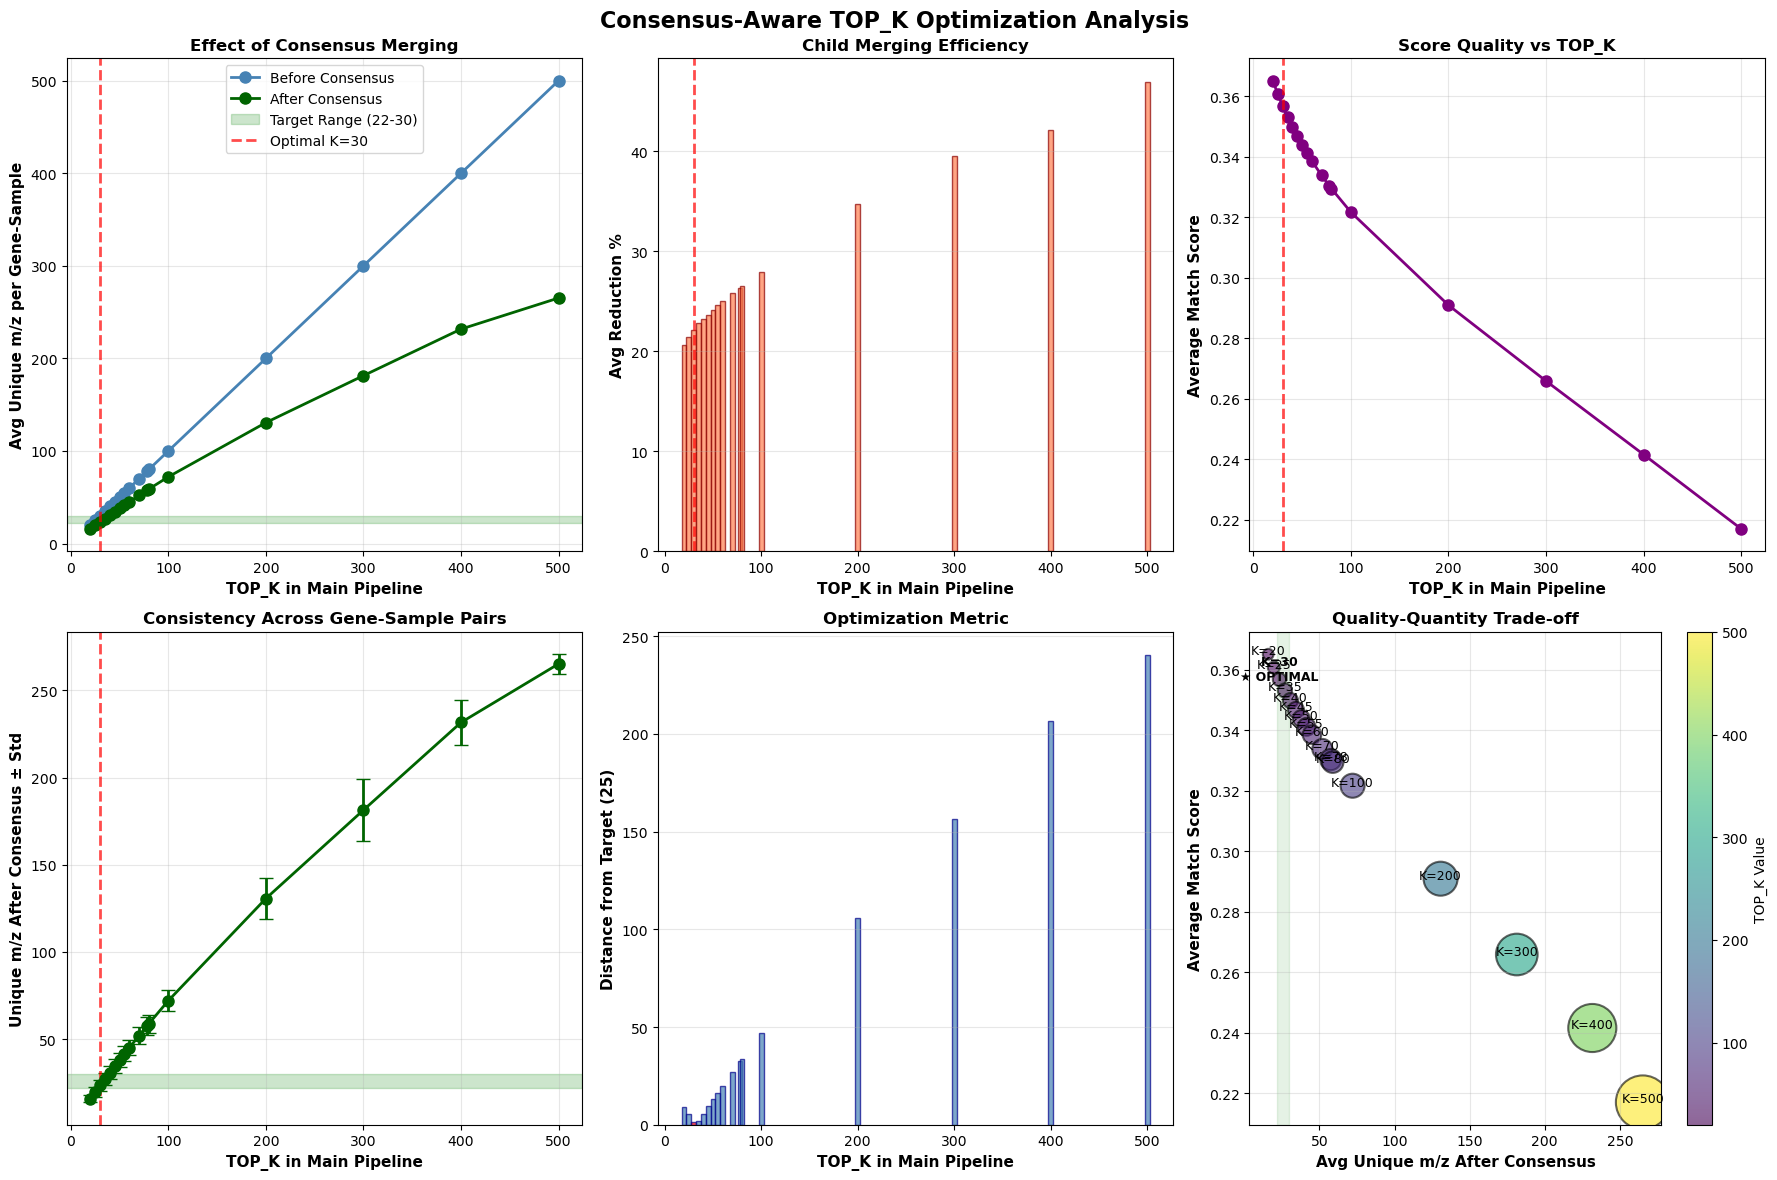


FINAL RECOMMENDATIONS

🎯 OPTIMAL TOP_K FOR MAIN PIPELINE: 30
   → Yields ~23.4 unique m/z per gene after consensus
   → Target range: 22-30 unique m/z
   → Reduction: ~22.2% from child merging
   → Average score: 0.3568

📊 ACCEPTABLE ALTERNATIVES:
   • TOP_K = 35: ~27.0 unique m/z, score = 0.3532

💡 INTERPRETATION:
   Set TOP_K_MATCHES = 30 in your main pipeline.
   After your consensus algorithm merges children into parents,
   you'll have ~23.4 unique m/z per gene-sample pair.
   This aligns perfectly with the median per-gene elbow of 22
   from the independent analysis, plus a discovery buffer.


✓ Results saved to: consensus_aware_top_k_analysis/consensus_aware_top_k_results.csv

ANALYSIS COMPLETE!

✓ Optimal TOP_K determined: 30
✓ All results saved to: consensus_aware_top_k_analysis/

Next steps:
  1. Set TOP_K_MATCHES = 30 in your main pipeline
  2. Run your main pipeline to generate top 30 matches
  3. Apply consensus algorithm to merge children and re-rank
  4. Final output: ~

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from itertools import combinations

# =============================================================================
# CONFIGURATION
# =============================================================================
INPUT_FILE = '500_gene_to_mz_synced_results_v1_analytic_fast/gene_to_mz_top500_matches_all_scores.csv'
PARENT_CHILD_FILE = "/home/ajarrah/PhD_Thesis/chapter_4/code_final/2_mz_synced_isotope_80_matching_results/parent_children_hierarchy.csv"
SAVE_DIR = "consensus_aware_top_k_analysis/"
os.makedirs(SAVE_DIR, exist_ok=True)

PRECISION = 4  # Decimal precision for m/z matching

# =============================================================================
# ELBOW DETECTION FUNCTIONS
# =============================================================================

def find_elbow_geometric(x, y):
    """Geometric method: Maximum distance from line connecting first and last points."""
    n_points = len(x)
    first_point = np.array([x[0], y[0]])
    line_vec = np.array([x[-1], y[-1]]) - first_point
    line_vec_norm = line_vec / np.sqrt(np.sum(line_vec**2))
    vec_from_first = np.array([x, y]).T - first_point
    scalar_proj = np.dot(vec_from_first, line_vec_norm)
    vec_proj = np.outer(scalar_proj, line_vec_norm)
    dist_to_line = np.sqrt(np.sum((vec_from_first - vec_proj)**2, axis=1))
    return x[np.argmax(dist_to_line)]

def find_elbow_derivative(x, y):
    """Second derivative method: Maximum curvature point."""
    dy = np.gradient(y)
    d2y = np.gradient(dy)
    return x[np.argmin(d2y)]

# =============================================================================
# PARENT-CHILD HIERARCHY LOADING
# =============================================================================

def load_parent_child_hierarchy(filepath):
    """
    Load parent-child relationships from validation file.
    Returns sets and mappings for parent-child filtering.
    """
    try:
        val_df = pd.read_csv(filepath)
        parent_set = set()
        child_set = set()
        child_to_parent = {}
        child_cols = [c for c in val_df.columns if 'Child' in c]
        
        for _, row in val_df.iterrows():
            if pd.isna(row['Parent_MZ']): 
                continue
            p_mz = round(float(row['Parent_MZ']), PRECISION)
            parent_set.add(p_mz)
            
            for col in child_cols:
                if col in row and pd.notna(row[col]) and str(row[col]).strip() != "":
                    c_mz = round(float(row[col]), PRECISION)
                    child_set.add(c_mz)
                    child_to_parent[c_mz] = p_mz
        
        print(f"Loaded hierarchy: {len(parent_set)} parents, {len(child_set)} children")
        return parent_set, child_set, child_to_parent
    except Exception as e:
        print(f"Error loading validation file: {e}")
        return set(), set(), {}

# =============================================================================
# CONSENSUS SIMULATION
# =============================================================================

def simulate_consensus_merging(df_subset, child_to_parent):
    """
    Simulate what the consensus algorithm will do:
    - Merge children into parents
    - Return unique m/z count after merging
    
    Args:
        df_subset: DataFrame subset for a specific gene/sample
        child_to_parent: Dictionary mapping child m/z to parent m/z
    
    Returns:
        dict with before/after merging statistics
    """
    # Get all unique m/z in this subset
    mz_list = [round(float(m), PRECISION) for m in df_subset['mz_feature'].unique()]
    unique_before = len(mz_list)
    
    # Simulate merging: remove children that have parents in the list
    unique_after_set = set(mz_list)
    children_removed = []
    
    for mz in mz_list:
        if mz in child_to_parent:
            parent = child_to_parent[mz]
            if parent in unique_after_set:
                unique_after_set.discard(mz)
                children_removed.append(mz)
    
    unique_after = len(unique_after_set)
    reduction = unique_before - unique_after
    reduction_pct = (reduction / unique_before * 100) if unique_before > 0 else 0
    
    return {
        'unique_before': unique_before,
        'unique_after': unique_after,
        'reduction': reduction,
        'reduction_pct': reduction_pct,
        'children_removed': len(children_removed)
    }

# =============================================================================
# COMPREHENSIVE TOP_K ANALYSIS FOR CONSENSUS PIPELINE
# =============================================================================

def analyze_top_k_for_consensus(file_path, parent_child_path, 
                                 test_k_values=[20, 30, 40, 45, 50, 60, 70, 78, 80, 100]):
    """
    Analyze different TOP_K values to determine optimal cutoff for main pipeline,
    accounting for subsequent consensus merging.
    
    This answers: "What TOP_K should I use in my main pipeline so that after
                   consensus merging, I get ~22-30 unique m/z per gene?"
    
    Args:
        file_path: Path to match results CSV
        parent_child_path: Path to parent-child hierarchy CSV
        test_k_values: List of TOP_K values to test
    
    Returns:
        DataFrame with analysis results
    """
    
    # Load data
    print("="*70)
    print("CONSENSUS-AWARE TOP_K ANALYSIS")
    print("="*70)
    print("\nThis analysis determines the optimal TOP_K for your main pipeline,")
    print("accounting for child-to-parent merging in the consensus algorithm.\n")
    
    try:
        df = pd.read_csv(file_path)
        print(f"✓ Loaded {len(df)} matches from input file")
    except FileNotFoundError:
        print(f"✗ Error: File {file_path} not found.")
        return None
    
    # Load parent-child hierarchy
    parent_set, child_set, child_to_parent = load_parent_child_hierarchy(parent_child_path)
    
    if not child_to_parent:
        print("✗ Warning: No parent-child relationships loaded!")
        print("  Analysis will proceed but merging simulation will be trivial.")
    
    # Standardize column names
    df.columns = [c.lower() for c in df.columns]
    
    print(f"\n{'='*70}")
    print("DATASET OVERVIEW")
    print(f"{'='*70}")
    print(f"  Total matches: {len(df)}")
    print(f"  Unique genes: {df['gene'].nunique()}")
    print(f"  Unique samples: {df['rna_sample'].nunique()}")
    print(f"  Unique m/z features: {df['mz_feature'].nunique()}")
    print(f"  Rank range: {df['rank'].min()} to {df['rank'].max()}")
    
    # =========================================================================
    # STAGE 1: ANALYZE EACH TOP_K VALUE
    # =========================================================================
    
    print(f"\n{'='*70}")
    print("STAGE 1: SIMULATING CONSENSUS MERGING AT DIFFERENT TOP_K VALUES")
    print(f"{'='*70}\n")
    
    all_results = []
    
    for k in test_k_values:
        print(f"Testing TOP_K = {k}...")
        
        # Filter to top K
        subset = df[df['rank'] <= k].copy()
        
        # Simulate consensus per gene-sample pair
        gene_sample_stats = []
        
        for (gene, sample), group in subset.groupby(['gene', 'rna_sample']):
            merge_stats = simulate_consensus_merging(group, child_to_parent)
            merge_stats['gene'] = gene
            merge_stats['sample'] = sample
            gene_sample_stats.append(merge_stats)
        
        # Aggregate statistics for this TOP_K
        stats_df = pd.DataFrame(gene_sample_stats)
        
        all_results.append({
            'TOP_K': k,
            'avg_unique_before': stats_df['unique_before'].mean(),
            'avg_unique_after': stats_df['unique_after'].mean(),
            'median_unique_after': stats_df['unique_after'].median(),
            'std_unique_after': stats_df['unique_after'].std(),
            'min_unique_after': stats_df['unique_after'].min(),
            'max_unique_after': stats_df['unique_after'].max(),
            'avg_reduction': stats_df['reduction'].mean(),
            'avg_reduction_pct': stats_df['reduction_pct'].mean(),
            'total_matches_before': len(subset),
            'avg_score': subset['combined_score'].mean(),
            'min_score': subset['combined_score'].min()
        })
        
        print(f"  → Before merging: {stats_df['unique_before'].mean():.1f} unique m/z per gene-sample")
        print(f"  → After merging:  {stats_df['unique_after'].mean():.1f} unique m/z per gene-sample")
        print(f"  → Reduction:      {stats_df['reduction_pct'].mean():.1f}%\n")
    
    results_df = pd.DataFrame(all_results)
    
    # =========================================================================
    # STAGE 2: FIND OPTIMAL TOP_K BASED ON TARGET
    # =========================================================================
    
    print(f"{'='*70}")
    print("STAGE 2: FINDING OPTIMAL TOP_K")
    print(f"{'='*70}\n")
    
    # Target based on per-gene elbow analysis (median = 22)
    TARGET_MIN = 22  # Median per-gene elbow from independent analysis
    TARGET_MAX = 30  # Buffer above median
    TARGET_IDEAL = 25  # Midpoint
    
    print(f"Target unique m/z after consensus: {TARGET_MIN}-{TARGET_MAX}")
    print(f"  (Based on median per-gene elbow of 22 from independent analysis)\n")
    
    # Calculate distance from target
    results_df['distance_from_target'] = abs(results_df['avg_unique_after'] - TARGET_IDEAL)
    
    # Find best TOP_K
    best_idx = results_df['distance_from_target'].idxmin()
    best_k = results_df.loc[best_idx, 'TOP_K']
    best_unique = results_df.loc[best_idx, 'avg_unique_after']
    
    # Also find TOP_K values within acceptable range
    acceptable = results_df[
        (results_df['avg_unique_after'] >= TARGET_MIN) & 
        (results_df['avg_unique_after'] <= TARGET_MAX)
    ].copy()
    
    print("="*70)
    print("RESULTS SUMMARY")
    print("="*70)
    print(f"\n{'TOP_K':<8} {'Before':<10} {'After':<10} {'Reduction':<12} {'Avg Score':<12} {'Min Score':<12}")
    print("-"*70)
    for _, row in results_df.iterrows():
        marker = " ← OPTIMAL" if row['TOP_K'] == best_k else ""
        marker = marker or (" ← IN RANGE" if row['TOP_K'] in acceptable['TOP_K'].values else "")
        print(f"{int(row['TOP_K']):<8} {row['avg_unique_before']:<10.1f} "
              f"{row['avg_unique_after']:<10.1f} {row['avg_reduction_pct']:<12.1f}% "
              f"{row['avg_score']:<12.4f} {row['min_score']:<12.4f}{marker}")
    
    # =========================================================================
    # STAGE 3: VISUALIZATION
    # =========================================================================
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # Plot 1: Unique m/z before vs after consensus
    ax1 = axes[0, 0]
    ax1.plot(results_df['TOP_K'], results_df['avg_unique_before'], 'o-', 
             linewidth=2, markersize=8, color='steelblue', label='Before Consensus')
    ax1.plot(results_df['TOP_K'], results_df['avg_unique_after'], 'o-', 
             linewidth=2, markersize=8, color='darkgreen', label='After Consensus')
    ax1.axhspan(TARGET_MIN, TARGET_MAX, alpha=0.2, color='green', label=f'Target Range ({TARGET_MIN}-{TARGET_MAX})')
    ax1.axvline(best_k, color='red', linestyle='--', linewidth=2, alpha=0.7, label=f'Optimal K={best_k}')
    ax1.set_xlabel('TOP_K in Main Pipeline', fontsize=11, fontweight='bold')
    ax1.set_ylabel('Avg Unique m/z per Gene-Sample', fontsize=11, fontweight='bold')
    ax1.set_title('Effect of Consensus Merging', fontsize=12, fontweight='bold')
    ax1.legend()
    ax1.grid(alpha=0.3)
    
    # Plot 2: Reduction percentage
    ax2 = axes[0, 1]
    ax2.bar(results_df['TOP_K'], results_df['avg_reduction_pct'], 
            color='coral', alpha=0.7, edgecolor='darkred', width=5)
    ax2.axvline(best_k, color='red', linestyle='--', linewidth=2, alpha=0.7)
    ax2.set_xlabel('TOP_K in Main Pipeline', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Avg Reduction %', fontsize=11, fontweight='bold')
    ax2.set_title('Child Merging Efficiency', fontsize=12, fontweight='bold')
    ax2.grid(alpha=0.3, axis='y')
    
    # Plot 3: Score quality vs TOP_K
    ax3 = axes[0, 2]
    ax3.plot(results_df['TOP_K'], results_df['avg_score'], 'o-', 
             linewidth=2, markersize=8, color='purple')
    ax3.axvline(best_k, color='red', linestyle='--', linewidth=2, alpha=0.7)
    ax3.set_xlabel('TOP_K in Main Pipeline', fontsize=11, fontweight='bold')
    ax3.set_ylabel('Average Match Score', fontsize=11, fontweight='bold')
    ax3.set_title('Score Quality vs TOP_K', fontsize=12, fontweight='bold')
    ax3.grid(alpha=0.3)
    
    # Plot 4: Variability after consensus
    ax4 = axes[1, 0]
    ax4.errorbar(results_df['TOP_K'], results_df['avg_unique_after'], 
                 yerr=results_df['std_unique_after'], fmt='o-', 
                 linewidth=2, markersize=8, capsize=5, color='darkgreen')
    ax4.axhspan(TARGET_MIN, TARGET_MAX, alpha=0.2, color='green')
    ax4.axvline(best_k, color='red', linestyle='--', linewidth=2, alpha=0.7)
    ax4.set_xlabel('TOP_K in Main Pipeline', fontsize=11, fontweight='bold')
    ax4.set_ylabel('Unique m/z After Consensus ± Std', fontsize=11, fontweight='bold')
    ax4.set_title('Consistency Across Gene-Sample Pairs', fontsize=12, fontweight='bold')
    ax4.grid(alpha=0.3)
    
    # Plot 5: Distance from target
    ax5 = axes[1, 1]
    colors = ['red' if k == best_k else 'steelblue' for k in results_df['TOP_K']]
    ax5.bar(results_df['TOP_K'], results_df['distance_from_target'], 
            color=colors, alpha=0.7, edgecolor='darkblue', width=5)
    ax5.set_xlabel('TOP_K in Main Pipeline', fontsize=11, fontweight='bold')
    ax5.set_ylabel('Distance from Target (25)', fontsize=11, fontweight='bold')
    ax5.set_title('Optimization Metric', fontsize=12, fontweight='bold')
    ax5.grid(alpha=0.3, axis='y')
    
    # Plot 6: Quality-Quantity trade-off
    ax6 = axes[1, 2]
    scatter = ax6.scatter(results_df['avg_unique_after'], results_df['avg_score'], 
                         s=results_df['TOP_K']*3, alpha=0.6, c=results_df['TOP_K'], 
                         cmap='viridis', edgecolors='black', linewidth=1.5)
    
    # Annotate each point
    for _, row in results_df.iterrows():
        label = f"K={int(row['TOP_K'])}"
        if row['TOP_K'] == best_k:
            label += "\n★ OPTIMAL"
        ax6.annotate(label, (row['avg_unique_after'], row['avg_score']), 
                    fontsize=9, ha='center', fontweight='bold' if row['TOP_K'] == best_k else 'normal')
    
    ax6.axvspan(TARGET_MIN, TARGET_MAX, alpha=0.1, color='green')
    ax6.set_xlabel('Avg Unique m/z After Consensus', fontsize=11, fontweight='bold')
    ax6.set_ylabel('Average Match Score', fontsize=11, fontweight='bold')
    ax6.set_title('Quality-Quantity Trade-off', fontsize=12, fontweight='bold')
    ax6.grid(alpha=0.3)
    
    plt.colorbar(scatter, ax=ax6, label='TOP_K Value')
    
    plt.suptitle('Consensus-Aware TOP_K Optimization Analysis', 
                 fontsize=16, fontweight='bold')
    plt.tight_layout()
    
    plot_path = os.path.join(SAVE_DIR, 'consensus_aware_top_k_analysis.png')
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    print(f"\n✓ Visualization saved to: {plot_path}")
    plt.show()
    
    # =========================================================================
    # STAGE 4: RECOMMENDATIONS
    # =========================================================================
    
    print(f"\n{'='*70}")
    print("FINAL RECOMMENDATIONS")
    print(f"{'='*70}\n")
    
    print(f"🎯 OPTIMAL TOP_K FOR MAIN PIPELINE: {int(best_k)}")
    print(f"   → Yields ~{best_unique:.1f} unique m/z per gene after consensus")
    print(f"   → Target range: {TARGET_MIN}-{TARGET_MAX} unique m/z")
    print(f"   → Reduction: ~{results_df.loc[best_idx, 'avg_reduction_pct']:.1f}% from child merging")
    print(f"   → Average score: {results_df.loc[best_idx, 'avg_score']:.4f}")
    
    if len(acceptable) > 1:
        print(f"\n📊 ACCEPTABLE ALTERNATIVES:")
        for _, row in acceptable.iterrows():
            if row['TOP_K'] != best_k:
                print(f"   • TOP_K = {int(row['TOP_K'])}: ~{row['avg_unique_after']:.1f} unique m/z, "
                      f"score = {row['avg_score']:.4f}")
    
    print(f"\n💡 INTERPRETATION:")
    print(f"   Set TOP_K_MATCHES = {int(best_k)} in your main pipeline.")
    print(f"   After your consensus algorithm merges children into parents,")
    print(f"   you'll have ~{best_unique:.1f} unique m/z per gene-sample pair.")
    print(f"   This aligns perfectly with the median per-gene elbow of 22")
    print(f"   from the independent analysis, plus a discovery buffer.")
    
    print(f"\n{'='*70}\n")
    
    # Save results
    results_path = os.path.join(SAVE_DIR, 'consensus_aware_top_k_results.csv')
    results_df.to_csv(results_path, index=False)
    print(f"✓ Results saved to: {results_path}\n")
    
    return results_df, best_k

# =============================================================================
# MAIN EXECUTION
# =============================================================================

if __name__ == "__main__":
    print("\n" + "="*70)
    print("CONSENSUS-AWARE TOP_K SELECTION FOR GENE-TO-M/Z PIPELINE")
    print("="*70)
    print("\nThis analysis determines the optimal TOP_K_MATCHES for your main")
    print("pipeline, accounting for child-to-parent merging in the consensus step.")
    print("="*70 + "\n")
    
    # Run analysis
    results_df, optimal_k = analyze_top_k_for_consensus(
        INPUT_FILE, 
        PARENT_CHILD_FILE,
        test_k_values=[20, 25, 30, 35, 40, 45, 50, 55, 60, 70, 78, 80, 100, 200, 300, 400, 500]
    )
    
    if results_df is not None:
        print("="*70)
        print("ANALYSIS COMPLETE!")
        print("="*70)
        print(f"\n✓ Optimal TOP_K determined: {int(optimal_k)}")
        print(f"✓ All results saved to: {SAVE_DIR}")
        print(f"\nNext steps:")
        print(f"  1. Set TOP_K_MATCHES = {int(optimal_k)} in your main pipeline")
        print(f"  2. Run your main pipeline to generate top {int(optimal_k)} matches")
        print(f"  3. Apply consensus algorithm to merge children and re-rank")
        print(f"  4. Final output: ~22-30 unique high-quality m/z per gene")
        print("="*70 + "\n")
